In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization, Conv1D, MaxPooling1D, GlobalAveragePooling1D, MultiHeadAttention
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from collections import Counter

## 1. Load & Merge Dataset

In [8]:
# 1. Load the datasets
df_malaysia = pd.read_csv('Malaysia 2000-01-01 to 2025-11-30.csv')
df_states = pd.read_csv('States 2020-01-01 to 2025-11-30.csv')

# 2. Convert 'datetime' safely (supports mixed formats)
df_malaysia['datetime'] = pd.to_datetime(df_malaysia['datetime'], format='mixed', dayfirst=True)
df_states['datetime'] = pd.to_datetime(df_states['datetime'], format='mixed', dayfirst=True)

# 3. Concatenate the dataframes
combined_df = pd.concat([df_malaysia, df_states], ignore_index=True)

# 4. Standardize the 'name' column
combined_df['name'] = combined_df['name'].astype(str).str.title()

# 5. Sort by name and datetime
combined_df = combined_df.sort_values(by=['name', 'datetime'])

# 6. Save the combined dataset
combined_df.to_csv('Combined_Malaysia_States_Weather_Data.csv', index=False)

## 2. Data Preprocessing

In [ ]:
# 1. Load the dataset
combined_df = pd.read_csv('Combined_Malaysia_States_Weather_Data.csv')

# --- User's Cleaning Code Start ---

# Drop 'snow' and 'snowdepth' as they are irrelevant for Malaysia (mostly 0 or NaN)
combined_df = combined_df.drop(columns=['snow', 'snowdepth'])

# Correct 'rain,snow' entry to 'rain'
# Note: In the previous turn, 'preciptype' was object.
combined_df['preciptype'] = combined_df['preciptype'].replace('rain,snow', 'rain')

# Fill missing 'preciptype' with "none"
combined_df['preciptype'] = combined_df['preciptype'].fillna('none')

# Fill missing 'severerisk' with 0
combined_df['severerisk'] = combined_df['severerisk'].fillna(0)

# Fill missing 'windgust' with the 'windspeed' value
combined_df['windgust'] = combined_df['windgust'].fillna(combined_df['windspeed'])

# 7. Impute Missing Values with Interpolation
def fill_missing_by_group(group):
    # Columns to interpolate linearly
    cols_to_interpolate = ['solarradiation', 'solarenergy', 'uvindex', 
                           'sealevelpressure', 'cloudcover', 'visibility']
    
    # Apply linear interpolation
    group[cols_to_interpolate] = group[cols_to_interpolate].interpolate(method='linear', limit_direction='both')
    return group

# Apply the imputation function grouped by location name
# Using group_keys=False to avoid MultiIndex creation if possible, or we reset index later
combined_df = combined_df.groupby('name', group_keys=False).apply(fill_missing_by_group)

# 8. Handle any remaining missing values (fallback)
cols_zero_fill = ['solarradiation', 'solarenergy', 'uvindex']
combined_df[cols_zero_fill] = combined_df[cols_zero_fill].fillna(0)

cols_mean_fill = ['sealevelpressure', 'cloudcover', 'visibility']
for col in cols_mean_fill:
    if combined_df[col].isnull().sum() > 0:
        combined_df[col] = combined_df[col].fillna(combined_df[col].mean())

# --- User's Cleaning Code End ---

# --- One-Hot Encoding Steps ---

# Select columns to encode
# We perform this AFTER the cleaning steps above
cols_to_encode = ['name', 'preciptype', 'conditions', 'icon']

# Perform one-hot encoding
# Using prefix to make column names clear (e.g., name_Johor)
# dtype=int ensures 1 and 0 instead of True/False
combined_df_encoded = pd.get_dummies(combined_df, columns=cols_to_encode, prefix=cols_to_encode, dtype=int)

# Check the result
print("Cleaned and Encoded DataFrame Info:")
print(combined_df_encoded.info())

# Save the final preprocessed data
output_filename = 'Cleaned_Encoded_Malaysia_Weather_Data.csv'
combined_df_encoded.to_csv(output_filename, index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_24452\2084293241.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df = combined_df.groupby('name', group_keys=False).apply(fill_missing_by_group)


Cleaned and Encoded DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 20252 entries, 0 to 20251
Data columns (total 47 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   datetime                                 20252 non-null  object 
 1   tempmax                                  20252 non-null  float64
 2   tempmin                                  20252 non-null  float64
 3   temp                                     20252 non-null  float64
 4   feelslikemax                             20252 non-null  float64
 5   feelslikemin                             20252 non-null  float64
 6   feelslike                                20252 non-null  float64
 7   dew                                      20252 non-null  float64
 8   humidity                                 20252 non-null  float64
 9   precip                                   20252 non-null  float64
 10  precipprob     

## 3. Coleration Heatmap


Correlation with Precipitation (precip):
precip                                     1.000000
visibility                                 0.244326
windgust                                   0.223242
windspeed                                  0.223117
conditions_Rain, Partially cloudy          0.154815
icon_rain                                  0.153353
precipprob                                 0.153353
name_Malaysia                              0.141572
humidity                                   0.135733
preciptype_rain                            0.130335
winddir                                    0.068999
precipcover                                0.066584
sealevelpressure                           0.029389
uvindex                                    0.011574
conditions_Snow, Rain, Partially cloudy   -0.001318
icon_clear-day                            -0.001889
conditions_Clear                          -0.001889
icon_wind                                 -0.003535
icon_fog              

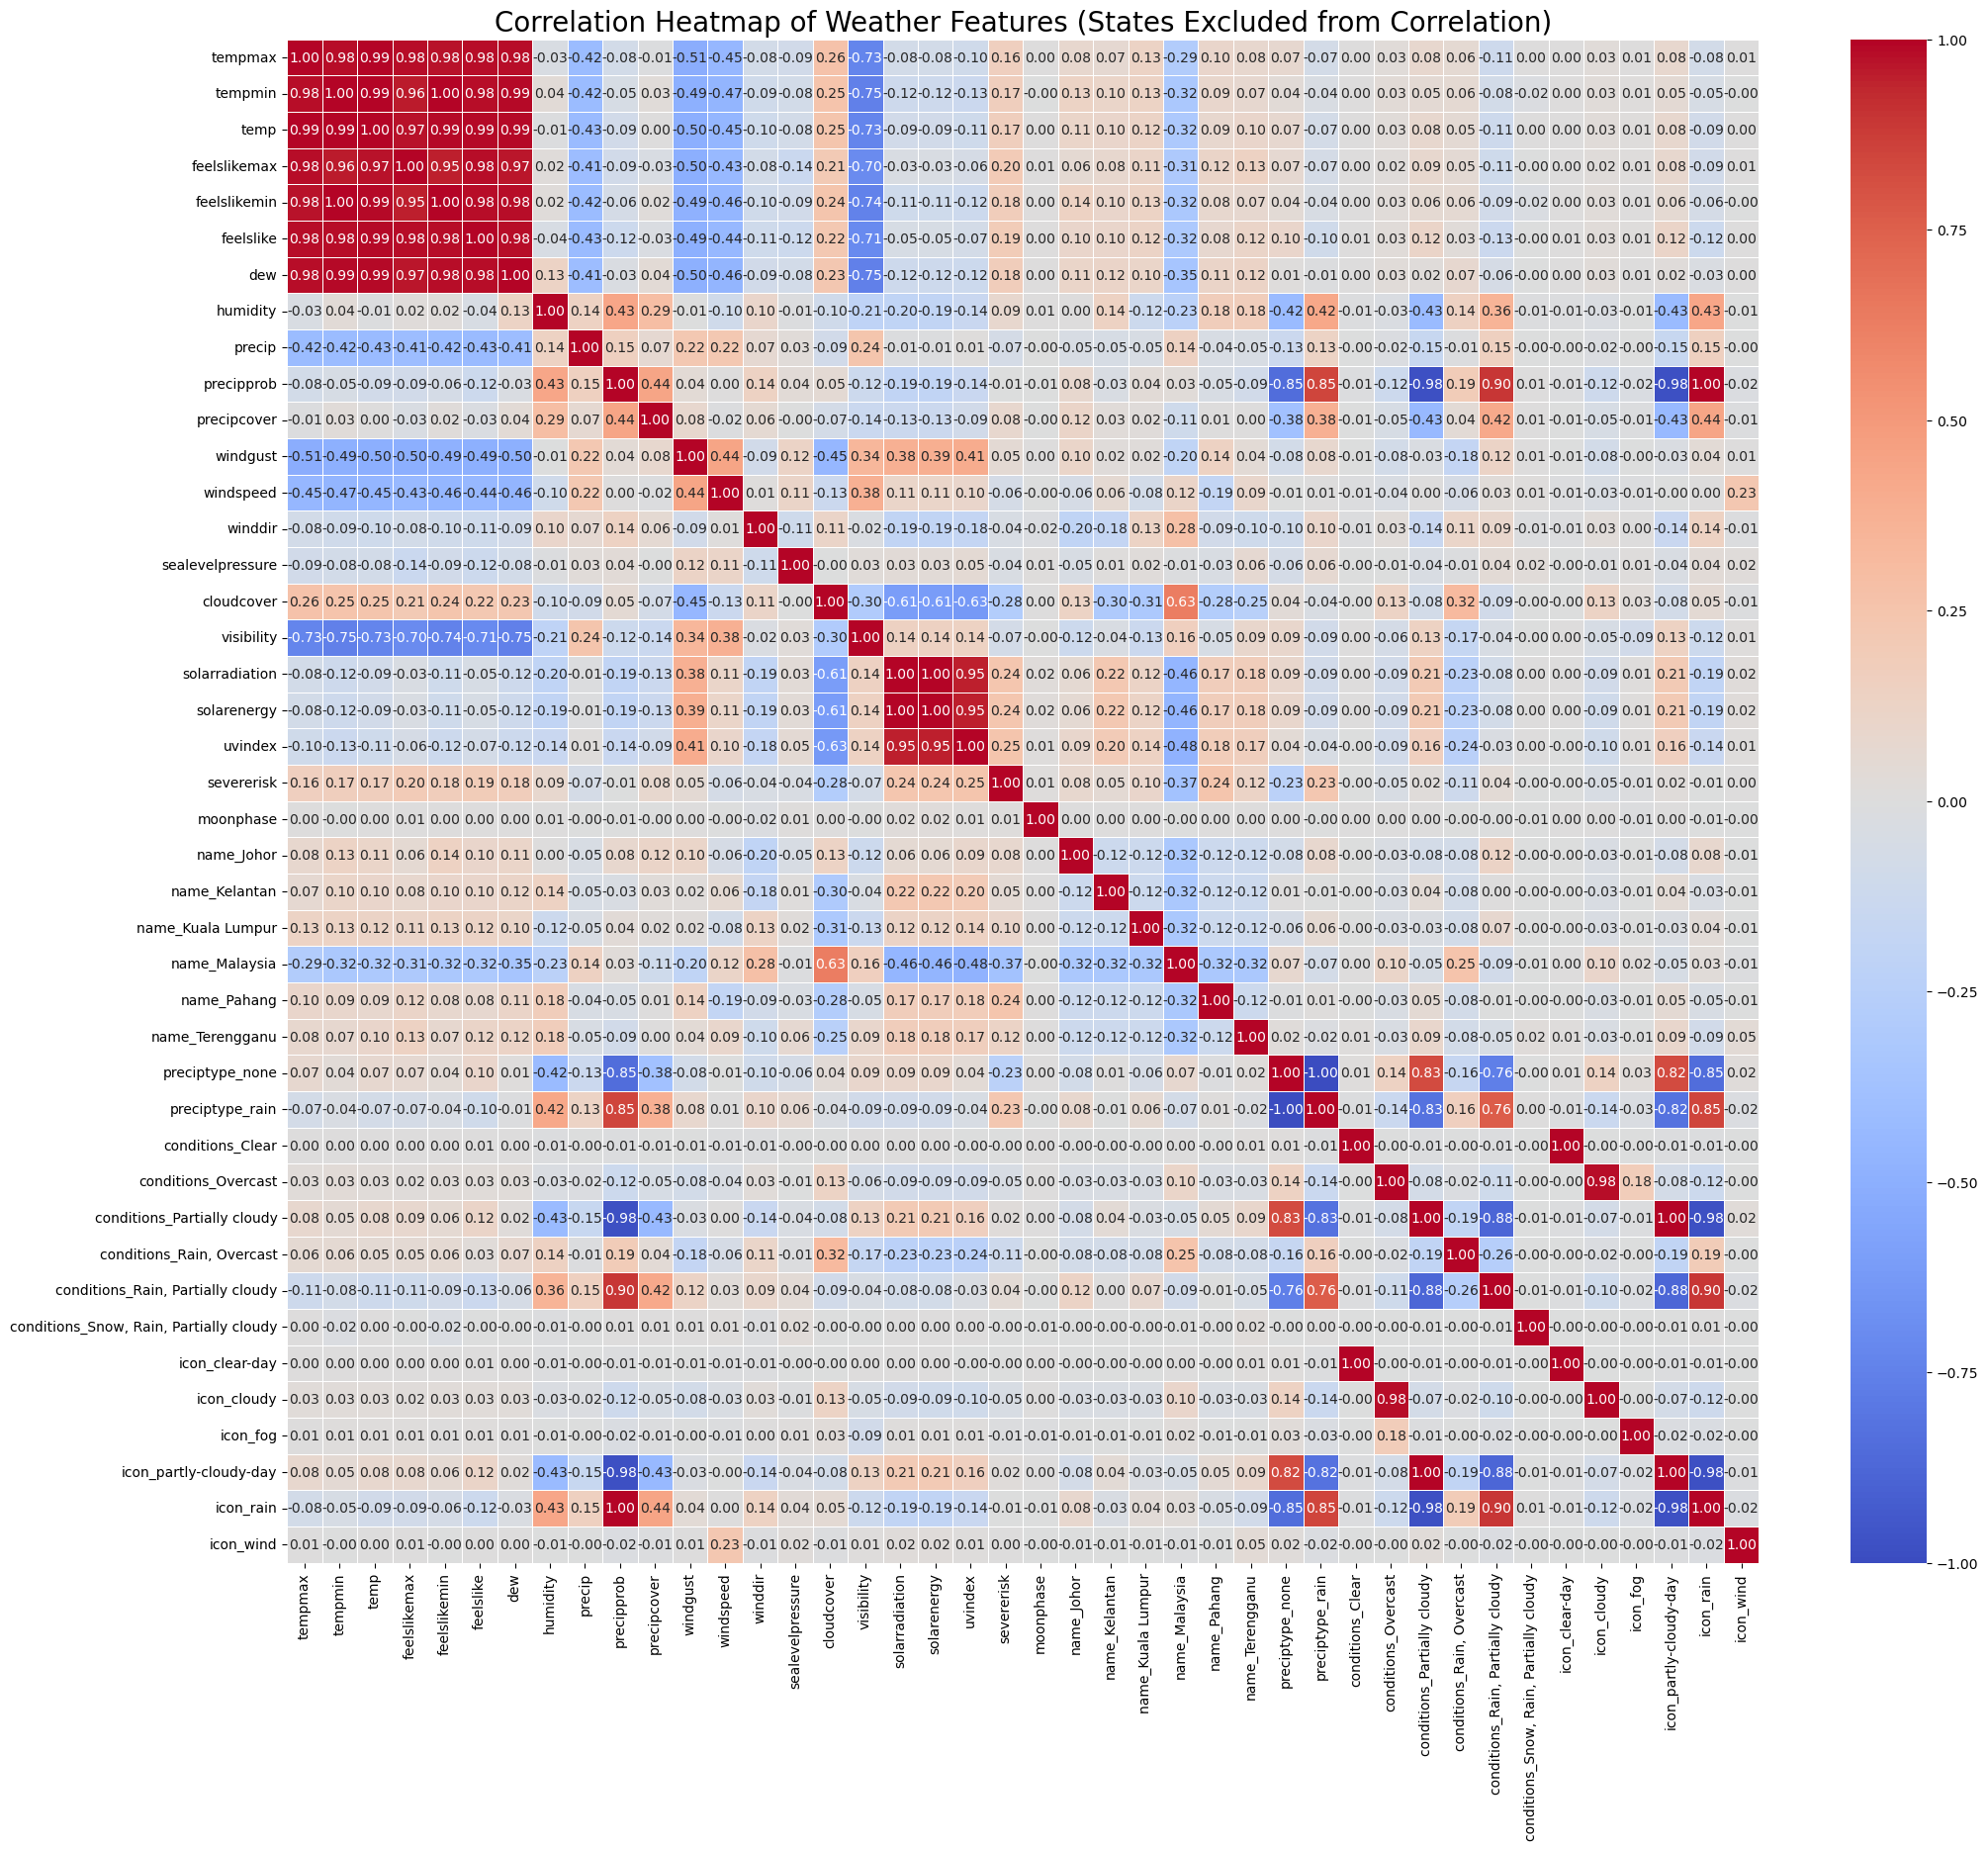

In [10]:
# Load the latest processed data (without state encoding)
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data.csv')

# Drop non-numeric columns for correlation calculation
# 'name', 'datetime', 'sunrise', 'sunset', 'description', 'stations' are non-numeric.
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create the heatmap
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap of Weather Features (States Excluded from Correlation)', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Get correlation with 'precip' and sort descending
precip_corr = corr_matrix['precip'].sort_values(ascending=False)

print("\nCorrelation with Precipitation (precip):")
print(precip_corr.to_string())

### LSTM

In [ ]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# 1. LOAD DAILY DATA
# ============================================================
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data.csv')

print("Total daily rows in dataset:", len(df))
df = df.reset_index(drop=True)

# ============================================================
# 2. DEFINE DAILY FEATURES
# ============================================================
feature_cols = [
    'precip',
    'visibility',
    'windspeed',
    'windgust',
    'conditions_Rain, Partially cloudy',
    'precipprob',
    'name_Malaysia',
    'icon_rain',
    'humidity',
    'preciptype_rain',
    'winddir',
    'precipcover',
    'sealevelpressure',
    'uvindex'
]

# ============================================================
# 3. CREATE DAILY BINARY TARGET: HEAVY VS NOT HEAVY
# ============================================================
# 0 = Not Heavy (<= 1.0 mm), 1 = Heavy (> 1.0 mm)
df['target_binary'] = (df['precip'] > 1.0).astype(int)

print("\nDaily class counts (0 = Not Heavy, 1 = Heavy):")
class_counts = df['target_binary'].value_counts()
print(class_counts)
print(f"Heavy rain percentage: {class_counts[1]/len(df)*100:.2f}%")

features = df[feature_cols].values
target   = df['target_binary'].values

# ============================================================
# 4. SCALE FEATURES
# ============================================================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# ============================================================
# 5. CREATE DAILY SEQUENCES
# ============================================================
def create_day_sequences(features, target, window_size_days):
    """
    X[i] = features for days t ... t+window_size_days-1
    y[i] = class of day t+window_size_days (NEXT day)
    """
    X, y = [], []
    for i in range(len(features) - window_size_days):
        X.append(features[i:i+window_size_days])
        y.append(target[i+window_size_days])
    return np.array(X), np.array(y)

# ============================================================
# 6. BUILD LSTM MODEL
# ============================================================
def build_lstm(
    input_shape,
    lstm_units=64,
    lstm_layers=2,
    dropout_rate=0.3
):
    """
    LSTM model with stacked LSTM layers.
    input_shape: (time_steps, num_features)
    """
    model = Sequential()
    
    # First LSTM layer(s)
    for i in range(lstm_layers):
        if i == 0:
            # First layer with input shape
            model.add(LSTM(
                units=lstm_units,
                return_sequences=(lstm_layers > 1 and i < lstm_layers - 1),
                input_shape=input_shape
            ))
        else:
            # Subsequent layers
            model.add(LSTM(
                units=lstm_units,
                return_sequences=(i < lstm_layers - 1)
            ))
        model.add(Dropout(dropout_rate))
    
    # Dense layer
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))
    
    # Output layer for 2 classes
    model.add(Dense(2, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hyperparameter grid for LSTM
LSTM_HPARAM_GRID = [
    {
        'lstm_units': 32,
        'lstm_layers': 1,
        'dropout_rate': 0.2
    },
    {
        'lstm_units': 64,
        'lstm_layers': 1,
        'dropout_rate': 0.3
    },
    {
        'lstm_units': 64,
        'lstm_layers': 2,
        'dropout_rate': 0.3
    },
    {
        'lstm_units': 128,
        'lstm_layers': 2,
        'dropout_rate': 0.3
    },
]

def most_common_hparams(hparams_list):
    """
    From a list of dicts, return the most frequent hparam setting.
    """
    if not hparams_list:
        # Fallback default
        return {
            'lstm_units': 64,
            'lstm_layers': 2,
            'dropout_rate': 0.3
        }
    # convert each dict to frozen set of items to make hashable
    key_map = {}
    keys = []
    for hp in hparams_list:
        k = frozenset(hp.items())
        key_map[k] = hp
        keys.append(k)
    c = Counter(keys)
    best_key, _ = c.most_common(1)[0]
    return key_map[best_key]

# ============================================================
# 7. TSCV + HYPERPARAM TUNING FOR LSTM
# ============================================================
DAY_WINDOW_SIZES = [1, 2, 3, 4]
window_cv_results = {}

print("\n" + "="*70)
print("LSTM: K-FOLD TIME SERIES CV + HYPERPARAM TUNING")
print("="*70)

for DAY_WINDOW_SIZE in DAY_WINDOW_SIZES:
    print(f"\n{'='*50}")
    print(f"Evaluating DAY_WINDOW_SIZE = {DAY_WINDOW_SIZE}")
    print(f"{'='*50}")
    
    X, y = create_day_sequences(features_scaled, target, window_size_days=DAY_WINDOW_SIZE)
    
    if len(X) < 60:
        print(f"Not enough samples for window size {DAY_WINDOW_SIZE}, skipping.")
        continue
    
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    y_cat = to_categorical(y, num_classes=2)
    
    tscv = TimeSeriesSplit(n_splits=5)
    fold_accuracies = []
    fold_best_hparams = []
    
    print("\nPerforming 5-Fold TimeSeries CV for LSTM:")
    print("-" * 50)
    
    for fold, (train_val_idx, test_idx) in enumerate(tscv.split(X), 1):
        print(f"\nFold {fold}/5:")
        print(f"Train+Val indices: {len(train_val_idx)} samples")
        print(f"Test indices: {len(test_idx)} samples")
        
        X_train_val = X[train_val_idx]
        y_train_val = y_cat[train_val_idx]
        X_test_fold = X[test_idx]
        y_test_fold = y_cat[test_idx]
        
        # Train/val split (80/20) inside train_val
        val_split_idx = int(len(X_train_val) * 0.8)
        X_train_fold = X_train_val[:val_split_idx]
        y_train_fold = y_train_val[:val_split_idx]
        X_val_fold   = X_train_val[val_split_idx:]
        y_val_fold   = y_train_val[val_split_idx:]
        
        print(f"  Train: {X_train_fold.shape[0]} samples")
        print(f"  Val:   {X_val_fold.shape[0]} samples")
        print(f"  Test:  {X_test_fold.shape[0]} samples")
        
        # Class weights on this fold
        y_train_int = np.argmax(y_train_fold, axis=1)
        class_weights_array = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train_int),
            y=y_train_int
        )
        class_weight_dict = dict(enumerate(class_weights_array))
        
        # Early stopping & LR scheduler
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.001,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=0
        )
        
        # Hyperparameter search on this fold (small grid)
        best_val_acc = -1.0
        best_hp_for_fold = None
        best_fold_model = None
        
        for hp in LSTM_HPARAM_GRID:
            print(f"    Trying HP: {hp}")
            
            model = build_lstm(
                input_shape=(X_train_fold.shape[1], X_train_fold.shape[2]),
                lstm_units=hp['lstm_units'],
                lstm_layers=hp['lstm_layers'],
                dropout_rate=hp['dropout_rate']
            )
            
            history = model.fit(
                X_train_fold, y_train_fold,
                epochs=80,
                batch_size=32,
                validation_data=(X_val_fold, y_val_fold),
                class_weight=class_weight_dict,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            # Evaluate on validation set
            y_val_pred_prob = model.predict(X_val_fold, verbose=0)
            y_val_pred = np.argmax(y_val_pred_prob, axis=1)
            y_val_true = np.argmax(y_val_fold, axis=1)
            val_acc = accuracy_score(y_val_true, y_val_pred)
            
            print(f"      Val Accuracy: {val_acc:.4f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_hp_for_fold = hp
                best_fold_model = model
        
        print(f"  Best HP for fold {fold}: {best_hp_for_fold} with Val Acc = {best_val_acc:.4f}")
        fold_best_hparams.append(best_hp_for_fold)
        
        # Evaluate best model of this fold on fold test set
        y_test_pred_prob = best_fold_model.predict(X_test_fold, verbose=0)
        y_test_pred = np.argmax(y_test_pred_prob, axis=1)
        y_test_true = np.argmax(y_test_fold, axis=1)
        
        fold_acc = accuracy_score(y_test_true, y_test_pred)
        fold_accuracies.append(fold_acc)
        
        print(f"  Fold {fold} Test Accuracy (LSTM): {fold_acc:.4f}")
        
        # Optional: print detailed metrics for first fold
        if fold == 1:
            print("\n  Fold 1 Classification Report (LSTM):")
            print(classification_report(
                y_test_true,
                y_test_pred,
                target_names=['Not Heavy', 'Heavy'],
                zero_division=0
            ))
    
    avg_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    window_cv_results[DAY_WINDOW_SIZE] = {
        'avg_accuracy': avg_accuracy,
        'std_accuracy': std_accuracy,
        'fold_accuracies': fold_accuracies,
        'best_hparams_per_fold': fold_best_hparams
    }
    
    print(f"\nSummary for window size {DAY_WINDOW_SIZE}:")
    print(f"  Average CV Accuracy: {avg_accuracy:.4f}")
    print(f"  Std Dev: {std_accuracy:.4f}")
    print(f"  Fold Accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")

# ============================================================
# 8. CHOOSE BEST WINDOW SIZE & HYPERPARAMS
# ============================================================
print("\n" + "="*70)
print("LSTM CROSS-VALIDATION RESULTS SUMMARY")
print("="*70)

best_window = None
best_accuracy = -1.0

for ws, results in window_cv_results.items():
    avg_acc = results['avg_accuracy']
    std_acc = results['std_accuracy']
    print(f"Window size {ws} days: {avg_acc:.4f} ± {std_acc:.4f}")
    if avg_acc > best_accuracy:
        best_accuracy = avg_acc
        best_window = ws

print(f"\n{'='*50}")
print(f"SELECTED BEST WINDOW SIZE (LSTM): {best_window} days")
print(f"Average CV Accuracy: {best_accuracy:.4f}")
print(f"{'='*50}")

# pick the most common hyperparams across folds for the best window
best_hp_final = most_common_hparams(
    window_cv_results[best_window]['best_hparams_per_fold']
)
print("\nMost common best hyperparameters for LSTM:")
print(best_hp_final)

# ============================================================
# 9. TRAIN FINAL LSTM MODEL (TRAIN/VAL/TEST SPLIT)
# ============================================================
print("\n" + "="*70)
print("TRAINING FINAL LSTM MODEL")
print("="*70)

X_all, y_all = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

split_idx = int(len(X_all) * 0.8)
X_train_val = X_all[:split_idx]
X_final_test = X_all[split_idx:]
y_train_val = y_all[:split_idx]
y_final_test = y_all[split_idx:]

print(f"Train+Val samples: {X_train_val.shape[0]}")
print(f"Final Test samples: {X_final_test.shape[0]}")

val_split_idx = int(len(X_train_val) * 0.8)
X_train_final = X_train_val[:val_split_idx]
X_val_final   = X_train_val[val_split_idx:]
y_train_final = y_train_val[:val_split_idx]
y_val_final   = y_train_val[val_split_idx:]

print("\nFinal split:")
print(f"  Training samples:   {X_train_final.shape[0]}")
print(f"  Validation samples: {X_val_final.shape[0]}")
print(f"  Test samples:       {X_final_test.shape[0]}")

# One-hot encode
y_train_final_cat = to_categorical(y_train_final, num_classes=2)
y_val_final_cat   = to_categorical(y_val_final, num_classes=2)
y_final_test_cat  = to_categorical(y_final_test, num_classes=2)

# Class weights for final train
y_train_int = np.argmax(y_train_final_cat, axis=1)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"\nClass weights (final LSTM): {class_weight_dict}")

# Build final LSTM with best hyperparams
final_lstm = build_lstm(
    input_shape=(X_train_final.shape[1], X_train_final.shape[2]),
    lstm_units=best_hp_final['lstm_units'],
    lstm_layers=best_hp_final['lstm_layers'],
    dropout_rate=best_hp_final['dropout_rate']
)

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1
)
reduce_lr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

print("\nTraining final LSTM model...")
final_history = final_lstm.fit(
    X_train_final, y_train_final_cat,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_final, y_val_final_cat),
    class_weight=class_weight_dict,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

# ============================================================
# 10. EVALUATE FINAL LSTM ON TEST SET
# ============================================================
print("\n" + "="*70)
print("FINAL LSTM MODEL EVALUATION")
print("="*70)

y_test_prob = final_lstm.predict(X_final_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)
y_test_true = np.argmax(y_final_test_cat, axis=1)

lstm_accuracy = accuracy_score(y_test_true, y_test_pred)

print("\nConfusion Matrix (Final LSTM):")
print(confusion_matrix(y_test_true, y_test_pred))

print("\nClassification Report (Final LSTM):")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Final LSTM Test Accuracy: {lstm_accuracy:.4f}")

# ============================================================
# 11. RANDOM FOREST BASELINE (UNCHANGED STYLE)
# ============================================================
print("\n" + "="*70)
print("RANDOM FOREST BASELINE WITH CV")
print("="*70)

# flatten sequences for RF
X_all_flat = X_all.reshape(X_all.shape[0], -1)
X_train_val_flat = X_all_flat[:split_idx]
X_test_flat      = X_all_flat[split_idx:]

print(f"RF Train+Val samples: {X_train_val_flat.shape[0]}")
print(f"RF Test samples:      {X_test_flat.shape[0]}")

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':    ['sqrt', 'log2']
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring='accuracy',
    cv=rf_tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nPerforming RandomizedSearchCV for RF baseline...")
rf_search.fit(X_train_val_flat, y_train_val)

print(f"\nBest RF Parameters: {rf_search.best_params_}")
print(f"Best RF CV Accuracy: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_flat)
rf_accuracy = accuracy_score(y_final_test, y_pred_rf)

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_final_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(
    y_final_test,
    y_pred_rf,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

# ============================================================
# 12. MODEL COMPARISON
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON: LSTM vs Random Forest")
print("="*70)

print(f"Best window size (LSTM): {best_window} days")
print(f"  LSTM Test Accuracy: {lstm_accuracy:.4f}")
print(f"  RF Test Accuracy  : {rf_accuracy:.4f}")
print(f"  Difference        : {abs(lstm_accuracy - rf_accuracy):.4f}")

# ============================================================
# 13. 180-DAY FORECAST WITH LSTM 
# ============================================================
print("\n" + "="*70)
print("PREDICTING NEXT 180 DAYS (LSTM)")
print("="*70)

X_forecast, y_forecast = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

if len(X_forecast) > 180:
    train_cutoff = len(X_forecast) - 180
    
    X_train_forecast = X_forecast[:train_cutoff]
    y_train_forecast = y_forecast[:train_cutoff]
    X_next180         = X_forecast[train_cutoff:]
    y_next180_true    = y_forecast[train_cutoff:]
    
    print(f"\nForecast Training samples: {X_train_forecast.shape[0]}")
    print(f"Next 180 days to predict:   {X_next180.shape[0]}")
    
    y_train_forecast_cat = to_categorical(y_train_forecast, num_classes=2)
    
    forecast_lstm = build_lstm(
        input_shape=(X_train_forecast.shape[1], X_train_forecast.shape[2]),
        lstm_units=best_hp_final['lstm_units'],
        lstm_layers=best_hp_final['lstm_layers'],
        dropout_rate=best_hp_final['dropout_rate']
    )
    
    forecast_lstm.fit(
        X_train_forecast, y_train_forecast_cat,
        epochs=100,
        batch_size=32,
        verbose=0
    )
    
    y_next180_prob = forecast_lstm.predict(X_next180, verbose=0)
    y_next180_pred = np.argmax(y_next180_prob, axis=1)
    
    print(f"\n{'='*70}")
    print(f"LSTM PREDICTIONS FOR NEXT 180 DAYS (Window Size: {best_window} days)")
    print(f"{'='*70}\n")
    
    print(f"{'Day':<6} {'Actual':<10} {'Predicted':<10} {'P(Not Heavy)':<15} {'P(Heavy)':<12}")
    print("-" * 70)
    
    for i in range(180):
        actual = y_next180_true[i]
        predicted = y_next180_pred[i]
        prob_not_heavy = y_next180_prob[i, 0]
        prob_heavy     = y_next180_prob[i, 1]
        print(
            f"Day +{i+1:2d}  {actual:<10} {predicted:<10} "
            f"{prob_not_heavy:.3f}{' ':11} {prob_heavy:.3f}"
        )
    
    print("-" * 70)
    
    forecast_accuracy = accuracy_score(y_next180_true, y_next180_pred)
    print(f"\n180-Day Forecast Accuracy (LSTM): {forecast_accuracy:.4f}")
    
    print("\nConfusion Matrix (180-Day Forecast, LSTM):")
    print(confusion_matrix(y_next180_true, y_next180_pred))

    print("\nClassification Report (180-Day Forecast, LSTM):")
    print(classification_report(
        y_next180_true,
        y_next180_pred,
        target_names=['Not Heavy', 'Heavy'],
        zero_division=0
    ))

else:
    print("Not enough data for 180-day LSTM forecast.")

# ============================================================
# 14. SUMMARY
# ============================================================
print("\n" + "="*70)
print("SUMMARY (LSTM PIPELINE)")
print("="*70)

print(f"\n1. Data Information:")
print(f"   Total samples: {len(df)}")
print(f"   Heavy rain days: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"   Not heavy days: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")

print("\n2. Cross-Validation Results (LSTM):")
for ws, results in window_cv_results.items():
    print(f"   Window {ws} days: {results['avg_accuracy']:.4f} ± {results['std_accuracy']:.4f}")

print("\n3. Final Model Performance:")
print(f"   Best window size (LSTM): {best_window} days")
print(f"   LSTM Test Accuracy: {lstm_accuracy:.4f}")
print(f"   Random Forest Test Accuracy: {rf_accuracy:.4f}")
if 'forecast_accuracy' in locals():
    print(f"   180-Day Forecast Accuracy (LSTM): {forecast_accuracy:.4f}")

print("\n" + "="*70)
print("PROCESS COMPLETED (LSTM)")
print("="*70)

Total daily rows in dataset: 20252

Daily class counts (0 = Not Heavy, 1 = Heavy):
target_binary
0    17843
1     2409
Name: count, dtype: int64
Heavy rain percentage: 11.90%

LSTM: K-FOLD TIME SERIES CV + HYPERPARAM TUNING

Evaluating DAY_WINDOW_SIZE = 1
X shape: (20251, 1, 14), y shape: (20251,)

Performing 5-Fold TimeSeries CV for LSTM:
--------------------------------------------------

Fold 1/5:
Train+Val indices: 3376 samples
Test indices: 3375 samples
  Train: 2700 samples
  Val:   676 samples
  Test:  3375 samples
    Trying HP: {'lstm_units': 32, 'lstm_layers': 1, 'dropout_rate': 0.2}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


      Val Accuracy: 0.4571
    Trying HP: {'lstm_units': 64, 'lstm_layers': 1, 'dropout_rate': 0.3}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


      Val Accuracy: 0.4911
    Trying HP: {'lstm_units': 64, 'lstm_layers': 2, 'dropout_rate': 0.3}


...

      Val Accuracy: 0.5357
  Best HP for fold 5: {'lstm_units': 64, 'lstm_layers': 1, 'dropout_rate': 0.3} with Val Acc = 0.5784
  Fold 5 Test Accuracy (LSTM): 0.6841

Summary for window size 4:
  Average CV Accuracy: 0.7276
  Std Dev: 0.0855
  Fold Accuracies: ['0.7534', '0.8838', '0.6624', '0.6544', '0.6841']

LSTM CROSS-VALIDATION RESULTS SUMMARY
Window size 1 days: 0.6101 ± 0.1574
Window size 2 days: 0.6953 ± 0.1563
Window size 3 days: 0.6606 ± 0.1113
Window size 4 days: 0.7276 ± 0.0855

SELECTED BEST WINDOW SIZE (LSTM): 4 days
Average CV Accuracy: 0.7276

Most common best hyperparameters for LSTM:
{'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.3}

TRAINING FINAL LSTM MODEL
Train+Val samples: 16198
Final Test samples: 4050

Final split:
  Training samples:   12958
  Validation samples: 3240
  Test samples:       4050

Class weights (final LSTM): {0: np.float64(0.5469818488813846), 1: np.float64(5.821203953279425)}

Training final LSTM model...
Epoch 1/150


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


405/405 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5511 - loss: 0.6770 - val_accuracy: 0.4960 - val_loss: 0.7091 - learning_rate: 0.0010
Epoch 2/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5628 - loss: 0.6673 - val_accuracy: 0.5102 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 3/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5793 - loss: 0.6614 - val_accuracy: 0.4744 - val_loss: 0.7116 - learning_rate: 0.0010
Epoch 4/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5560 - loss: 0.6616 - val_accuracy: 0.4802 - val_loss: 0.7062 - learning_rate: 0.0010
Epoch 5/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5320 - loss: 0.6632 - val_accuracy: 0.5685 - val_loss: 0.6785 - learning_rate: 0.0010
Epoch 6/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5944 - loss: 0.6600 - val_accuracy: 0.5043 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 7/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5825 - loss: 0.6581 -

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



LSTM PREDICTIONS FOR NEXT 180 DAYS (Window Size: 4 days)

Day    Actual     Predicted  P(Not Heavy)    P(Heavy)    
----------------------------------------------------------------------
Day + 1  0          0          0.963            0.037
Day + 2  0          0          0.986            0.014
Day + 3  0          0          1.000            0.000
Day + 4  0          0          0.988            0.012
Day + 5  0          0          0.875            0.125
Day + 6  0          0          0.917            0.083
Day + 7  0          0          0.901            0.099
Day + 8  0          0          0.955            0.045
Day + 9  0          0          0.987            0.013
Day +10  0          0          0.955            0.045
Day +11  0          0          0.999            0.001
Day +12  0          0          0.945            0.055
Day +13  0          0          0.871            0.129
Day +14  0          0          0.959            0.041
Day +15  0          0          1.000            0.000
Da

### 1D-CNN

In [ ]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# 1. LOAD DAILY DATA
# ============================================================
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data.csv')

print("Total daily rows in dataset:", len(df))
df = df.reset_index(drop=True)

# ============================================================
# 2. DEFINE DAILY FEATURES
# ============================================================
feature_cols = [
    'precip',
    'visibility',
    'windspeed',
    'windgust',
    'conditions_Rain, Partially cloudy',
    'precipprob',
    'name_Malaysia',
    'icon_rain',
    'humidity',
    'preciptype_rain',
    'winddir',
    'precipcover',
    'sealevelpressure',
    'uvindex'
]

# ============================================================
# 3. CREATE DAILY BINARY TARGET: HEAVY VS NOT HEAVY
# ============================================================
# 0 = Not Heavy (<= 1.0 mm), 1 = Heavy (> 1.0 mm)
df['target_binary'] = (df['precip'] > 1.0).astype(int)

print("\nDaily class counts (0 = Not Heavy, 1 = Heavy):")
class_counts = df['target_binary'].value_counts()
print(class_counts)
print(f"Heavy rain percentage: {class_counts[1]/len(df)*100:.2f}%")

features = df[feature_cols].values
target   = df['target_binary'].values

# ============================================================
# 4. SCALE FEATURES
# ============================================================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# ============================================================
# 5. CREATE DAILY SEQUENCES
# ============================================================
def create_day_sequences(features, target, window_size_days):
    """
    X[i] = features for days t ... t+window_size_days-1
    y[i] = class of day t+window_size_days (NEXT day)
    """
    X, y = [], []
    for i in range(len(features) - window_size_days):
        X.append(features[i:i+window_size_days])
        y.append(target[i+window_size_days])
    return np.array(X), np.array(y)

# ============================================================
# 6. BUILD 1D-CNN MODEL
# ============================================================
def build_cnn(
    input_shape,
    filters=64,
    kernel_size=3,
    dense_units=32,
    dropout_rate=0.3,
    use_pooling=True
):
    """
    1D-CNN model for heavy/not-heavy classification.
    input_shape: (time_steps, num_features)
    """
    model = Sequential()
    
    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        activation='relu',
        padding='same',
        input_shape=input_shape
    ))

    # Only pool if have at least 2 time steps
    if use_pooling and input_shape[0] >= 2:
        model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        activation='relu',
        padding='same'
    ))

    model.add(GlobalAveragePooling1D())
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))
    
    # Output layer for 2 classes
    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hyperparameter grid for 1D-CNN
CNN_HPARAM_GRID = [
    {
        'filters': 32,
        'kernel_size': 3,
        'dense_units': 32,
        'dropout_rate': 0.3
    },
    {
        'filters': 64,
        'kernel_size': 3,
        'dense_units': 32,
        'dropout_rate': 0.3
    },
    {
        'filters': 64,
        'kernel_size': 5,
        'dense_units': 64,
        'dropout_rate': 0.4
    },
]

def most_common_hparams(hparams_list):
    """
    From a list of dicts, return the most frequent hparam setting.
    """
    if not hparams_list:
        # Fallback default
        return {
            'filters': 64,
            'kernel_size': 3,
            'dense_units': 32,
            'dropout_rate': 0.3
        }
    # convert each dict to frozen set of items to make hashable
    key_map = {}
    keys = []
    for hp in hparams_list:
        k = frozenset(hp.items())
        key_map[k] = hp
        keys.append(k)
    c = Counter(keys)
    best_key, _ = c.most_common(1)[0]
    return key_map[best_key]

# ============================================================
# 7. TSCV + HYPERPARAM TUNING FOR 1D-CNN
# ============================================================
DAY_WINDOW_SIZES = [1, 2, 3, 4]
window_cv_results = {}

print("\n" + "="*70)
print("1D-CNN: K-FOLD TIME SERIES CV + HYPERPARAM TUNING")
print("="*70)

for DAY_WINDOW_SIZE in DAY_WINDOW_SIZES:
    print(f"\n{'='*50}")
    print(f"Evaluating DAY_WINDOW_SIZE = {DAY_WINDOW_SIZE}")
    print(f"{'='*50}")
    
    X, y = create_day_sequences(features_scaled, target, window_size_days=DAY_WINDOW_SIZE)
    
    if len(X) < 60:
        print(f"Not enough samples for window size {DAY_WINDOW_SIZE}, skipping.")
        continue
    
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    y_cat = to_categorical(y, num_classes=2)
    
    tscv = TimeSeriesSplit(n_splits=5)
    fold_accuracies = []
    fold_best_hparams = []
    
    print("\nPerforming 5-Fold TimeSeries CV for 1D-CNN:")
    print("-" * 50)
    
    for fold, (train_val_idx, test_idx) in enumerate(tscv.split(X), 1):
        print(f"\nFold {fold}/5:")
        print(f"Train+Val indices: {len(train_val_idx)} samples")
        print(f"Test indices: {len(test_idx)} samples")
        
        X_train_val = X[train_val_idx]
        y_train_val = y_cat[train_val_idx]
        X_test_fold = X[test_idx]
        y_test_fold = y_cat[test_idx]
        
        # Train/val split (80/20) inside train_val
        val_split_idx = int(len(X_train_val) * 0.8)
        X_train_fold = X_train_val[:val_split_idx]
        y_train_fold = y_train_val[:val_split_idx]
        X_val_fold   = X_train_val[val_split_idx:]
        y_val_fold   = y_train_val[val_split_idx:]
        
        print(f"  Train: {X_train_fold.shape[0]} samples")
        print(f"  Val:   {X_val_fold.shape[0]} samples")
        print(f"  Test:  {X_test_fold.shape[0]} samples")
        
        # Class weights on this fold
        y_train_int = np.argmax(y_train_fold, axis=1)
        class_weights_array = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train_int),
            y=y_train_int
        )
        class_weight_dict = dict(enumerate(class_weights_array))
        
        # Early stopping & LR scheduler
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.001,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=0
        )
        
        # Hyperparameter search on this fold
        best_val_acc = -1.0
        best_hp_for_fold = None
        best_fold_model = None
        
        for hp in CNN_HPARAM_GRID:
            print(f"    Trying HP: {hp}")
            
            model = build_cnn(
                input_shape=(X_train_fold.shape[1], X_train_fold.shape[2]),
                filters=hp['filters'],
                kernel_size=hp['kernel_size'],
                dense_units=hp['dense_units'],
                dropout_rate=hp['dropout_rate'],
                use_pooling=(DAY_WINDOW_SIZE >= 2)
            )
            
            history = model.fit(
                X_train_fold, y_train_fold,
                epochs=80,
                batch_size=32,
                validation_data=(X_val_fold, y_val_fold),
                class_weight=class_weight_dict,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            # Evaluate on validation set
            y_val_pred_prob = model.predict(X_val_fold, verbose=0)
            y_val_pred = np.argmax(y_val_pred_prob, axis=1)
            y_val_true = np.argmax(y_val_fold, axis=1)
            val_acc = accuracy_score(y_val_true, y_val_pred)
            
            print(f"      Val Accuracy: {val_acc:.4f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_hp_for_fold = hp
                best_fold_model = model
        
        print(f"  Best HP for fold {fold}: {best_hp_for_fold} with Val Acc = {best_val_acc:.4f}")
        fold_best_hparams.append(best_hp_for_fold)
        
        # Evaluate best model of this fold on fold test set
        y_test_pred_prob = best_fold_model.predict(X_test_fold, verbose=0)
        y_test_pred = np.argmax(y_test_pred_prob, axis=1)
        y_test_true = np.argmax(y_test_fold, axis=1)
        
        fold_acc = accuracy_score(y_test_true, y_test_pred)
        fold_accuracies.append(fold_acc)
        
        print(f"  Fold {fold} Test Accuracy (1D-CNN): {fold_acc:.4f}")
        
        # Optional: print detailed metrics for first fold
        if fold == 1:
            print("\n  Fold 1 Classification Report (1D-CNN):")
            print(classification_report(
                y_test_true,
                y_test_pred,
                target_names=['Not Heavy', 'Heavy'],
                zero_division=0
            ))
    
    avg_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    window_cv_results[DAY_WINDOW_SIZE] = {
        'avg_accuracy': avg_accuracy,
        'std_accuracy': std_accuracy,
        'fold_accuracies': fold_accuracies,
        'best_hparams_per_fold': fold_best_hparams
    }
    
    print(f"\nSummary for window size {DAY_WINDOW_SIZE}:")
    print(f"  Average CV Accuracy: {avg_accuracy:.4f}")
    print(f"  Std Dev: {std_accuracy:.4f}")
    print(f"  Fold Accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")

# ============================================================
# 8. CHOOSE BEST WINDOW SIZE & HYPERPARAMS
# ============================================================
print("\n" + "="*70)
print("1D-CNN CROSS-VALIDATION RESULTS SUMMARY")
print("="*70)

best_window = None
best_accuracy = -1.0

for ws, results in window_cv_results.items():
    avg_acc = results['avg_accuracy']
    std_acc = results['std_accuracy']
    print(f"Window size {ws} days: {avg_acc:.4f} ± {std_acc:.4f}")
    if avg_acc > best_accuracy:
        best_accuracy = avg_acc
        best_window = ws

print(f"\n{'='*50}")
print(f"SELECTED BEST WINDOW SIZE (1D-CNN): {best_window} days")
print(f"Average CV Accuracy: {best_accuracy:.4f}")
print(f"{'='*50}")

# pick the most common hyperparams across folds for the best window
best_hp_final = most_common_hparams(
    window_cv_results[best_window]['best_hparams_per_fold']
)
print("\nMost common best hyperparameters for 1D-CNN:")
print(best_hp_final)

# ============================================================
# 9. TRAIN FINAL 1D-CNN MODEL (TRAIN/VAL/TEST SPLIT)
# ============================================================
print("\n" + "="*70)
print("TRAINING FINAL 1D-CNN MODEL")
print("="*70)

X_all, y_all = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

split_idx = int(len(X_all) * 0.8)
X_train_val = X_all[:split_idx]
X_final_test = X_all[split_idx:]
y_train_val = y_all[:split_idx]
y_final_test = y_all[split_idx:]

print(f"Train+Val samples: {X_train_val.shape[0]}")
print(f"Final Test samples: {X_final_test.shape[0]}")

val_split_idx = int(len(X_train_val) * 0.8)
X_train_final = X_train_val[:val_split_idx]
X_val_final   = X_train_val[val_split_idx:]
y_train_final = y_train_val[:val_split_idx]
y_val_final   = y_train_val[val_split_idx:]

print("\nFinal split:")
print(f"  Training samples:   {X_train_final.shape[0]}")
print(f"  Validation samples: {X_val_final.shape[0]}")
print(f"  Test samples:       {X_final_test.shape[0]}")

# One-hot encode
y_train_final_cat = to_categorical(y_train_final, num_classes=2)
y_val_final_cat   = to_categorical(y_val_final, num_classes=2)
y_final_test_cat  = to_categorical(y_final_test, num_classes=2)

# Class weights for final train
y_train_int = np.argmax(y_train_final_cat, axis=1)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"\nClass weights (final 1D-CNN): {class_weight_dict}")

# Build final 1D-CNN with best hyperparams
final_cnn = build_cnn(
    input_shape=(X_train_final.shape[1], X_train_final.shape[2]),
    filters=best_hp_final['filters'],
    kernel_size=best_hp_final['kernel_size'],
    dense_units=best_hp_final['dense_units'],
    dropout_rate=best_hp_final['dropout_rate'],
    use_pooling=(best_window >= 2)
)

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1
)
reduce_lr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

print("\nTraining final 1D-CNN model...")
final_history = final_cnn.fit(
    X_train_final, y_train_final_cat,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_final, y_val_final_cat),
    class_weight=class_weight_dict,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

# ============================================================
# 10. EVALUATE FINAL 1D-CNN ON TEST SET
# ============================================================
print("\n" + "="*70)
print("FINAL 1D-CNN MODEL EVALUATION")
print("="*70)

y_test_prob = final_cnn.predict(X_final_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)
y_test_true = np.argmax(y_final_test_cat, axis=1)

cnn_accuracy = accuracy_score(y_test_true, y_test_pred)

print("\nConfusion Matrix (Final 1D-CNN):")
print(confusion_matrix(y_test_true, y_test_pred))

print("\nClassification Report (Final 1D-CNN):")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Final 1D-CNN Test Accuracy: {cnn_accuracy:.4f}")

# ============================================================
# 11. RANDOM FOREST BASELINE (UNCHANGED STYLE)
# ============================================================
print("\n" + "="*70)
print("RANDOM FOREST BASELINE WITH CV")
print("="*70)

# flatten sequences for RF
X_all_flat = X_all.reshape(X_all.shape[0], -1)
X_train_val_flat = X_all_flat[:split_idx]
X_test_flat      = X_all_flat[split_idx:]

print(f"RF Train+Val samples: {X_train_val_flat.shape[0]}")
print(f"RF Test samples:      {X_test_flat.shape[0]}")

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':    ['sqrt', 'log2']
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring='accuracy',
    cv=rf_tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nPerforming RandomizedSearchCV for RF baseline...")
rf_search.fit(X_train_val_flat, y_train_val)

print(f"\nBest RF Parameters: {rf_search.best_params_}")
print(f"Best RF CV Accuracy: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_flat)
rf_accuracy = accuracy_score(y_final_test, y_pred_rf)

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_final_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(
    y_final_test,
    y_pred_rf,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

# ============================================================
# 12. MODEL COMPARISON
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON: 1D-CNN vs Random Forest")
print("="*70)

print(f"Best window size (1D-CNN): {best_window} days")
print(f"  1D-CNN Test Accuracy: {cnn_accuracy:.4f}")
print(f"  RF Test Accuracy    : {rf_accuracy:.4f}")
print(f"  Difference          : {abs(cnn_accuracy - rf_accuracy):.4f}")

# ============================================================
# 13. 180-DAY FORECAST WITH 1D-CNN (KEEPING STYLE)
# ============================================================
print("\n" + "="*70)
print("PREDICTING NEXT 180 DAYS (1D-CNN)")
print("="*70)

X_forecast, y_forecast = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

if len(X_forecast) > 180:
    train_cutoff = len(X_forecast) - 180
    
    X_train_forecast = X_forecast[:train_cutoff]
    y_train_forecast = y_forecast[:train_cutoff]
    X_next180         = X_forecast[train_cutoff:]
    y_next180_true    = y_forecast[train_cutoff:]
    
    print(f"\nForecast Training samples: {X_train_forecast.shape[0]}")
    print(f"Next 180 days to predict:   {X_next180.shape[0]}")
    
    y_train_forecast_cat = to_categorical(y_train_forecast, num_classes=2)
    
    forecast_cnn = build_cnn(
        input_shape=(X_train_forecast.shape[1], X_train_forecast.shape[2]),
        filters=best_hp_final['filters'],
        kernel_size=best_hp_final['kernel_size'],
        dense_units=best_hp_final['dense_units'],
        dropout_rate=best_hp_final['dropout_rate'],
        use_pooling=(best_window >= 2)
    )
    
    forecast_cnn.fit(
        X_train_forecast, y_train_forecast_cat,
        epochs=100,
        batch_size=32,
        verbose=0
    )
    
    y_next180_prob = forecast_cnn.predict(X_next180, verbose=0)
    y_next180_pred = np.argmax(y_next180_prob, axis=1)
    
    print(f"\n{'='*70}")
    print(f"1D-CNN PREDICTIONS FOR NEXT 180 DAYS (Window Size: {best_window} days)")
    print(f"{'='*70}\n")
    
    print(f"{'Day':<6} {'Actual':<10} {'Predicted':<10} {'P(Not Heavy)':<15} {'P(Heavy)':<12}")
    print("-" * 70)
    
    for i in range(180):
        actual = y_next180_true[i]
        predicted = y_next180_pred[i]
        prob_not_heavy = y_next180_prob[i, 0]
        prob_heavy     = y_next180_prob[i, 1]
        print(
            f"Day +{i+1:2d}  {actual:<10} {predicted:<10} "
            f"{prob_not_heavy:.3f}{' ':11} {prob_heavy:.3f}"
        )
    
    print("-" * 70)
    
    forecast_accuracy = accuracy_score(y_next180_true, y_next180_pred)
    print(f"\n180-Day Forecast Accuracy (1D-CNN): {forecast_accuracy:.4f}")
    
    print("\nConfusion Matrix (180-Day Forecast, 1D-CNN):")
    print(confusion_matrix(y_next180_true, y_next180_pred))

    print("\nClassification Report (180-Day Forecast, 1D-CNN):")
    print(classification_report(
        y_next180_true,
        y_next180_pred,
        target_names=['Not Heavy', 'Heavy'],
        zero_division=0
    ))

else:
    print("Not enough data for 60-day 1D-CNN forecast.")

# ============================================================
# 14. SUMMARY
# ============================================================
print("\n" + "="*70)
print("SUMMARY (1D-CNN PIPELINE)")
print("="*70)

print(f"\n1. Data Information:")
print(f"   Total samples: {len(df)}")
print(f"   Heavy rain days: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"   Not heavy days: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")

print("\n2. Cross-Validation Results (1D-CNN):")
for ws, results in window_cv_results.items():
    print(f"   Window {ws} days: {results['avg_accuracy']:.4f} ± {results['std_accuracy']:.4f}")

print("\n3. Final Model Performance:")
print(f"   Best window size (1D-CNN): {best_window} days")
print(f"   1D-CNN Test Accuracy: {cnn_accuracy:.4f}")
print(f"   Random Forest Test Accuracy: {rf_accuracy:.4f}")
if 'forecast_accuracy' in locals():
    print(f"   180-Day Forecast Accuracy (1D-CNN): {forecast_accuracy:.4f}")

print("\n" + "="*70)
print("PROCESS COMPLETED (1D-CNN)")
print("="*70)

Total daily rows in dataset: 20252

Daily class counts (0 = Not Heavy, 1 = Heavy):
target_binary
0    17843
1     2409
Name: count, dtype: int64
Heavy rain percentage: 11.90%

1D-CNN: K-FOLD TIME SERIES CV + HYPERPARAM TUNING

Evaluating DAY_WINDOW_SIZE = 1
X shape: (20251, 1, 14), y shape: (20251,)

Performing 5-Fold TimeSeries CV for 1D-CNN:
--------------------------------------------------

Fold 1/5:
Train+Val indices: 3376 samples
Test indices: 3375 samples
  Train: 2700 samples
  Val:   676 samples
  Test:  3375 samples
    Trying HP: {'filters': 32, 'kernel_size': 3, 'dense_units': 32, 'dropout_rate': 0.3}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


      Val Accuracy: 0.4675
    Trying HP: {'filters': 64, 'kernel_size': 3, 'dense_units': 32, 'dropout_rate': 0.3}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


      Val Accuracy: 0.6080
    Trying HP: {'filters': 64, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.4}


...

      Val Accuracy: 0.5479
  Best HP for fold 5: {'filters': 64, 'kernel_size': 3, 'dense_units': 32, 'dropout_rate': 0.3} with Val Acc = 0.5502
  Fold 5 Test Accuracy (1D-CNN): 0.7193

Summary for window size 4:
  Average CV Accuracy: 0.7039
  Std Dev: 0.1404
  Fold Accuracies: ['0.8112', '0.8746', '0.4718', '0.6426', '0.7193']

1D-CNN CROSS-VALIDATION RESULTS SUMMARY
Window size 1 days: 0.6898 ± 0.1893
Window size 2 days: 0.7489 ± 0.1401
Window size 3 days: 0.6769 ± 0.1195
Window size 4 days: 0.7039 ± 0.1404

SELECTED BEST WINDOW SIZE (1D-CNN): 2 days
Average CV Accuracy: 0.7489

Most common best hyperparameters for 1D-CNN:
{'filters': 64, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.4}

TRAINING FINAL 1D-CNN MODEL
Train+Val samples: 16200
Final Test samples: 4050

Final split:
  Training samples:   12960
  Validation samples: 3240
  Test samples:       4050

Class weights (final 1D-CNN): {0: np.float64(0.546973917447455), 1: np.float64(5.822102425876011)}

Training final 1

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4992 - loss: 0.6843 - val_accuracy: 0.4762 - val_loss: 0.6951 - learning_rate: 0.0010
Epoch 2/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5061 - loss: 0.6621 - val_accuracy: 0.5605 - val_loss: 0.6639 - learning_rate: 0.0010
Epoch 3/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5259 - loss: 0.6594 - val_accuracy: 0.6015 - val_loss: 0.6507 - learning_rate: 0.0010
Epoch 4/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5569 - loss: 0.6573 - val_accuracy: 0.5938 - val_loss: 0.6597 - learning_rate: 0.0010
Epoch 5/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5886 - loss: 0.6527 - val_accuracy: 0.6040 - val_loss: 0.6577 - learning_rate: 0.0010
Epoch 6/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5878 - loss: 0.6517 - val_accuracy: 0.6012 - val_loss: 0.6558 - learning_rate: 0.0010
Epoch 7/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5851 - loss: 0.6489 - val_a

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



1D-CNN PREDICTIONS FOR NEXT 180 DAYS (Window Size: 2 days)

Day    Actual     Predicted  P(Not Heavy)    P(Heavy)    
----------------------------------------------------------------------
Day + 1  0          0          0.948            0.052
Day + 2  0          0          0.991            0.009
Day + 3  0          0          0.966            0.034
Day + 4  0          0          1.000            0.000
Day + 5  0          0          0.954            0.046
Day + 6  0          0          0.905            0.095
Day + 7  0          0          0.966            0.034
Day + 8  0          0          0.978            0.022
Day + 9  0          0          0.968            0.032
Day +10  0          0          0.960            0.040
Day +11  0          0          0.953            0.047
Day +12  0          0          0.963            0.037
Day +13  0          0          0.955            0.045
Day +14  0          0          1.000            0.000
Day +15  0          0          0.960            0.040


### Transformer

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# 1. LOAD DAILY DATA
# ============================================================
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data.csv')

print("Total daily rows in dataset:", len(df))
df = df.reset_index(drop=True)

# ============================================================
# 2. DEFINE DAILY FEATURES
# ============================================================
feature_cols = [
    'precip',
    'visibility',
    'windspeed',
    'windgust',
    'conditions_Rain, Partially cloudy',
    'precipprob',
    'name_Malaysia',
    'icon_rain',
    'humidity',
    'preciptype_rain',
    'winddir',
    'precipcover',
    'sealevelpressure',
    'uvindex'
]

# ============================================================
# 3. CREATE DAILY BINARY TARGET: HEAVY VS NOT HEAVY
# ============================================================
# 0 = Not Heavy (<= 1.0 mm), 1 = Heavy (> 1.0 mm)
df['target_binary'] = (df['precip'] > 1.0).astype(int)

print("\nDaily class counts (0 = Not Heavy, 1 = Heavy):")
class_counts = df['target_binary'].value_counts()
print(class_counts)
print(f"Heavy rain percentage: {class_counts[1]/len(df)*100:.2f}%")

features = df[feature_cols].values
target   = df['target_binary'].values

# ============================================================
# 4. SCALE FEATURES
# ============================================================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# ============================================================
# 5. CREATE DAILY SEQUENCES
# ============================================================
def create_day_sequences(features, target, window_size_days):
    """
    X[i] = features for days t ... t+window_size_days-1
    y[i] = class of day t+window_size_days (NEXT day)
    """
    X, y = [], []
    for i in range(len(features) - window_size_days):
        X.append(features[i:i+window_size_days])
        y.append(target[i+window_size_days])
    return np.array(X), np.array(y)

# ============================================================
# 6. BUILD TRANSFORMER MODEL
# ============================================================
def transformer_encoder(inputs, num_heads=4, ff_dim=64, dropout=0.1):
    """
    Transformer encoder block with multi-head attention
    """
    attn_output = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=inputs.shape[-1]
    )(inputs, inputs)

    x = LayerNormalization(epsilon=1e-6)(inputs + attn_output)

    ff = Dense(ff_dim, activation='relu')(x)
    ff = Dropout(dropout)(ff)
    ff = Dense(inputs.shape[-1])(ff)

    x = LayerNormalization(epsilon=1e-6)(x + ff)
    return x

def build_transformer(
    input_shape,
    num_heads=4,
    ff_dim=64,
    dropout=0.3,
    num_encoder_blocks=1
):
    """
    Transformer model for heavy/not-heavy classification.
    input_shape: (time_steps, num_features)
    """
    inputs = Input(shape=input_shape)
    
    x = inputs
    # Stack multiple transformer encoder blocks
    for _ in range(num_encoder_blocks):
        x = transformer_encoder(x, num_heads=num_heads, ff_dim=ff_dim, dropout=dropout)
    
    # Global pooling and classification head
    x = GlobalAveragePooling1D()(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout)(x)
    
    # Output layer for 2 classes
    outputs = Dense(2, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hyperparameter grid for Transformer
TRANSFORMER_HPARAM_GRID = [
    {
        'num_heads': 2,
        'ff_dim': 32,
        'dropout': 0.2,
        'num_encoder_blocks': 1
    },
    {
        'num_heads': 4,
        'ff_dim': 64,
        'dropout': 0.3,
        'num_encoder_blocks': 1
    },
    {
        'num_heads': 4,
        'ff_dim': 128,
        'dropout': 0.3,
        'num_encoder_blocks': 1
    },
    {
        'num_heads': 4,
        'ff_dim': 64,
        'dropout': 0.3,
        'num_encoder_blocks': 2
    },
]

def most_common_hparams(hparams_list):
    """
    From a list of dicts, return the most frequent hparam setting.
    """
    if not hparams_list:
        # Fallback default
        return {
            'num_heads': 4,
            'ff_dim': 64,
            'dropout': 0.3,
            'num_encoder_blocks': 1
        }
    # convert each dict to frozen set of items to make hashable
    key_map = {}
    keys = []
    for hp in hparams_list:
        k = frozenset(hp.items())
        key_map[k] = hp
        keys.append(k)
    c = Counter(keys)
    best_key, _ = c.most_common(1)[0]
    return key_map[best_key]

# ============================================================
# 7. TSCV + HYPERPARAM TUNING FOR TRANSFORMER
# ============================================================
DAY_WINDOW_SIZES = [1, 2, 3, 4]
window_cv_results = {}

print("\n" + "="*70)
print("TRANSFORMER: K-FOLD TIME SERIES CV + HYPERPARAM TUNING")
print("="*70)

for DAY_WINDOW_SIZE in DAY_WINDOW_SIZES:
    print(f"\n{'='*50}")
    print(f"Evaluating DAY_WINDOW_SIZE = {DAY_WINDOW_SIZE}")
    print(f"{'='*50}")
    
    X, y = create_day_sequences(features_scaled, target, window_size_days=DAY_WINDOW_SIZE)
    
    if len(X) < 60:
        print(f"Not enough samples for window size {DAY_WINDOW_SIZE}, skipping.")
        continue
    
    print(f"X shape: {X.shape}, y shape: {y.shape}")
    y_cat = to_categorical(y, num_classes=2)
    
    tscv = TimeSeriesSplit(n_splits=5)
    fold_accuracies = []
    fold_best_hparams = []
    
    print("\nPerforming 5-Fold TimeSeries CV for Transformer:")
    print("-" * 50)
    
    for fold, (train_val_idx, test_idx) in enumerate(tscv.split(X), 1):
        print(f"\nFold {fold}/5:")
        print(f"Train+Val indices: {len(train_val_idx)} samples")
        print(f"Test indices: {len(test_idx)} samples")
        
        X_train_val = X[train_val_idx]
        y_train_val = y_cat[train_val_idx]
        X_test_fold = X[test_idx]
        y_test_fold = y_cat[test_idx]
        
        # Train/val split (80/20) inside train_val
        val_split_idx = int(len(X_train_val) * 0.8)
        X_train_fold = X_train_val[:val_split_idx]
        y_train_fold = y_train_val[:val_split_idx]
        X_val_fold   = X_train_val[val_split_idx:]
        y_val_fold   = y_train_val[val_split_idx:]
        
        print(f"  Train: {X_train_fold.shape[0]} samples")
        print(f"  Val:   {X_val_fold.shape[0]} samples")
        print(f"  Test:  {X_test_fold.shape[0]} samples")
        
        # Class weights on this fold
        y_train_int = np.argmax(y_train_fold, axis=1)
        class_weights_array = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train_int),
            y=y_train_int
        )
        class_weight_dict = dict(enumerate(class_weights_array))
        
        # Early stopping & LR scheduler
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.001,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=0
        )
        
        # Hyperparameter search on this fold
        best_val_acc = -1.0
        best_hp_for_fold = None
        best_fold_model = None
        
        for hp in TRANSFORMER_HPARAM_GRID:
            print(f"    Trying HP: {hp}")
            
            model = build_transformer(
                input_shape=(X_train_fold.shape[1], X_train_fold.shape[2]),
                num_heads=hp['num_heads'],
                ff_dim=hp['ff_dim'],
                dropout=hp['dropout'],
                num_encoder_blocks=hp['num_encoder_blocks']
            )
            
            history = model.fit(
                X_train_fold, y_train_fold,
                epochs=80,
                batch_size=32,
                validation_data=(X_val_fold, y_val_fold),
                class_weight=class_weight_dict,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )
            
            # Evaluate on validation set
            y_val_pred_prob = model.predict(X_val_fold, verbose=0)
            y_val_pred = np.argmax(y_val_pred_prob, axis=1)
            y_val_true = np.argmax(y_val_fold, axis=1)
            val_acc = accuracy_score(y_val_true, y_val_pred)
            
            print(f"      Val Accuracy: {val_acc:.4f}")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_hp_for_fold = hp
                best_fold_model = model
        
        print(f"  Best HP for fold {fold}: {best_hp_for_fold} with Val Acc = {best_val_acc:.4f}")
        fold_best_hparams.append(best_hp_for_fold)
        
        # Evaluate best model of this fold on fold test set
        y_test_pred_prob = best_fold_model.predict(X_test_fold, verbose=0)
        y_test_pred = np.argmax(y_test_pred_prob, axis=1)
        y_test_true = np.argmax(y_test_fold, axis=1)
        
        fold_acc = accuracy_score(y_test_true, y_test_pred)
        fold_accuracies.append(fold_acc)
        
        print(f"  Fold {fold} Test Accuracy (Transformer): {fold_acc:.4f}")
        
        # Optional: print detailed metrics for first fold
        if fold == 1:
            print("\n  Fold 1 Classification Report (Transformer):")
            print(classification_report(
                y_test_true,
                y_test_pred,
                target_names=['Not Heavy', 'Heavy'],
                zero_division=0
            ))
    
    avg_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    window_cv_results[DAY_WINDOW_SIZE] = {
        'avg_accuracy': avg_accuracy,
        'std_accuracy': std_accuracy,
        'fold_accuracies': fold_accuracies,
        'best_hparams_per_fold': fold_best_hparams
    }
    
    print(f"\nSummary for window size {DAY_WINDOW_SIZE}:")
    print(f"  Average CV Accuracy: {avg_accuracy:.4f}")
    print(f"  Std Dev: {std_accuracy:.4f}")
    print(f"  Fold Accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")

# ============================================================
# 8. CHOOSE BEST WINDOW SIZE & HYPERPARAMS
# ============================================================
print("\n" + "="*70)
print("TRANSFORMER CROSS-VALIDATION RESULTS SUMMARY")
print("="*70)

best_window = None
best_accuracy = -1.0

for ws, results in window_cv_results.items():
    avg_acc = results['avg_accuracy']
    std_acc = results['std_accuracy']
    print(f"Window size {ws} days: {avg_acc:.4f} ± {std_acc:.4f}")
    if avg_acc > best_accuracy:
        best_accuracy = avg_acc
        best_window = ws

print(f"\n{'='*50}")
print(f"SELECTED BEST WINDOW SIZE (TRANSFORMER): {best_window} days")
print(f"Average CV Accuracy: {best_accuracy:.4f}")
print(f"{'='*50}")

# pick the most common hyperparams across folds for the best window
best_hp_final = most_common_hparams(
    window_cv_results[best_window]['best_hparams_per_fold']
)
print("\nMost common best hyperparameters for Transformer:")
print(best_hp_final)

# ============================================================
# 9. TRAIN FINAL TRANSFORMER MODEL (TRAIN/VAL/TEST SPLIT)
# ============================================================
print("\n" + "="*70)
print("TRAINING FINAL TRANSFORMER MODEL")
print("="*70)

X_all, y_all = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

split_idx = int(len(X_all) * 0.8)
X_train_val = X_all[:split_idx]
X_final_test = X_all[split_idx:]
y_train_val = y_all[:split_idx]
y_final_test = y_all[split_idx:]

print(f"Train+Val samples: {X_train_val.shape[0]}")
print(f"Final Test samples: {X_final_test.shape[0]}")

val_split_idx = int(len(X_train_val) * 0.8)
X_train_final = X_train_val[:val_split_idx]
X_val_final   = X_train_val[val_split_idx:]
y_train_final = y_train_val[:val_split_idx]
y_val_final   = y_train_val[val_split_idx:]

print("\nFinal split:")
print(f"  Training samples:   {X_train_final.shape[0]}")
print(f"  Validation samples: {X_val_final.shape[0]}")
print(f"  Test samples:       {X_final_test.shape[0]}")

# One-hot encode
y_train_final_cat = to_categorical(y_train_final, num_classes=2)
y_val_final_cat   = to_categorical(y_val_final, num_classes=2)
y_final_test_cat  = to_categorical(y_final_test, num_classes=2)

# Class weights for final train
y_train_int = np.argmax(y_train_final_cat, axis=1)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"\nClass weights (final Transformer): {class_weight_dict}")

# Build final Transformer with best hyperparams
final_transformer = build_transformer(
    input_shape=(X_train_final.shape[1], X_train_final.shape[2]),
    num_heads=best_hp_final['num_heads'],
    ff_dim=best_hp_final['ff_dim'],
    dropout=best_hp_final['dropout'],
    num_encoder_blocks=best_hp_final['num_encoder_blocks']
)

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1
)
reduce_lr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

print("\nTraining final Transformer model...")
final_history = final_transformer.fit(
    X_train_final, y_train_final_cat,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_final, y_val_final_cat),
    class_weight=class_weight_dict,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

# ============================================================
# 10. EVALUATE FINAL TRANSFORMER ON TEST SET
# ============================================================
print("\n" + "="*70)
print("FINAL TRANSFORMER MODEL EVALUATION")
print("="*70)

y_test_prob = final_transformer.predict(X_final_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)
y_test_true = np.argmax(y_final_test_cat, axis=1)

transformer_accuracy = accuracy_score(y_test_true, y_test_pred)

print("\nConfusion Matrix (Final Transformer):")
print(confusion_matrix(y_test_true, y_test_pred))

print("\nClassification Report (Final Transformer):")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Final Transformer Test Accuracy: {transformer_accuracy:.4f}")

# ============================================================
# 11. RANDOM FOREST BASELINE (UNCHANGED STYLE)
# ============================================================
print("\n" + "="*70)
print("RANDOM FOREST BASELINE WITH CV")
print("="*70)

# flatten sequences for RF
X_all_flat = X_all.reshape(X_all.shape[0], -1)
X_train_val_flat = X_all_flat[:split_idx]
X_test_flat      = X_all_flat[split_idx:]

print(f"RF Train+Val samples: {X_train_val_flat.shape[0]}")
print(f"RF Test samples:      {X_test_flat.shape[0]}")

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':    ['sqrt', 'log2']
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring='accuracy',
    cv=rf_tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nPerforming RandomizedSearchCV for RF baseline...")
rf_search.fit(X_train_val_flat, y_train_val)

print(f"\nBest RF Parameters: {rf_search.best_params_}")
print(f"Best RF CV Accuracy: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_flat)
rf_accuracy = accuracy_score(y_final_test, y_pred_rf)

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_final_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(
    y_final_test,
    y_pred_rf,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

# ============================================================
# 12. MODEL COMPARISON
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON: TRANSFORMER vs Random Forest")
print("="*70)

print(f"Best window size (Transformer): {best_window} days")
print(f"  Transformer Test Accuracy: {transformer_accuracy:.4f}")
print(f"  RF Test Accuracy         : {rf_accuracy:.4f}")
print(f"  Difference               : {abs(transformer_accuracy - rf_accuracy):.4f}")

# ============================================================
# 13. 180-DAY FORECAST WITH TRANSFORMER (KEEPING STYLE)
# ============================================================
print("\n" + "="*70)
print("PREDICTING NEXT 180 DAYS (TRANSFORMER)")
print("="*70)

X_forecast, y_forecast = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

if len(X_forecast) > 180:
    train_cutoff = len(X_forecast) - 180
    
    X_train_forecast = X_forecast[:train_cutoff]
    y_train_forecast = y_forecast[:train_cutoff]
    X_next180         = X_forecast[train_cutoff:]
    y_next180_true    = y_forecast[train_cutoff:]
    
    print(f"\nForecast Training samples: {X_train_forecast.shape[0]}")
    print(f"Next 180 days to predict:   {X_next180.shape[0]}")
    
    y_train_forecast_cat = to_categorical(y_train_forecast, num_classes=2)
    
    forecast_transformer = build_transformer(
        input_shape=(X_train_forecast.shape[1], X_train_forecast.shape[2]),
        num_heads=best_hp_final['num_heads'],
        ff_dim=best_hp_final['ff_dim'],
        dropout=best_hp_final['dropout'],
        num_encoder_blocks=best_hp_final['num_encoder_blocks']
    )
    
    forecast_transformer.fit(
        X_train_forecast, y_train_forecast_cat,
        epochs=100,
        batch_size=32,
        verbose=0
    )
    
    y_next180_prob = forecast_transformer.predict(X_next180, verbose=0)
    y_next180_pred = np.argmax(y_next180_prob, axis=1)
    
    print(f"\n{'='*70}")
    print(f"TRANSFORMER PREDICTIONS FOR NEXT 180 DAYS (Window Size: {best_window} days)")
    print(f"{'='*70}\n")
    
    print(f"{'Day':<6} {'Actual':<10} {'Predicted':<10} {'P(Not Heavy)':<15} {'P(Heavy)':<12}")
    print("-" * 70)

    for i in range(180):
        actual = y_next180_true[i]
        predicted = y_next180_pred[i]
        prob_not_heavy = y_next180_prob[i, 0]
        prob_heavy     = y_next180_prob[i, 1]
        print(
            f"Day +{i+1:2d}  {actual:<10} {predicted:<10} "
            f"{prob_not_heavy:.3f}{' ':11} {prob_heavy:.3f}"
        )
    
    print("-" * 70)

    forecast_accuracy = accuracy_score(y_next180_true, y_next180_pred)
    print(f"\n180-Day Forecast Accuracy (Transformer): {forecast_accuracy:.4f}")

    print("\nConfusion Matrix (180-Day Forecast, Transformer):")
    print(confusion_matrix(y_next180_true, y_next180_pred))

    print("\nClassification Report (180-Day Forecast, Transformer):")
    print(classification_report(
        y_next180_true,
        y_next180_pred,
        target_names=['Not Heavy', 'Heavy'],
        zero_division=0
    ))

else:
    print("Not enough data for 60-day Transformer forecast.")

# ============================================================
# 14. SUMMARY
# ============================================================
print("\n" + "="*70)
print("SUMMARY (TRANSFORMER PIPELINE)")
print("="*70)

print(f"\n1. Data Information:")
print(f"   Total samples: {len(df)}")
print(f"   Heavy rain days: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"   Not heavy days: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")

print("\n2. Cross-Validation Results (Transformer):")
for ws, results in window_cv_results.items():
    print(f"   Window {ws} days: {results['avg_accuracy']:.4f} ± {results['std_accuracy']:.4f}")

print("\n3. Final Model Performance:")
print(f"   Best window size (Transformer): {best_window} days")
print(f"   Transformer Test Accuracy: {transformer_accuracy:.4f}")
print(f"   Random Forest Test Accuracy: {rf_accuracy:.4f}")
if 'forecast_accuracy' in locals():
    print(f"   180-Day Forecast Accuracy (Transformer): {forecast_accuracy:.4f}")

print("\n" + "="*70)
print("PROCESS COMPLETED (TRANSFORMER)")
print("="*70)

Total daily rows in dataset: 20252

Daily class counts (0 = Not Heavy, 1 = Heavy):
target_binary
0    17843
1     2409
Name: count, dtype: int64
Heavy rain percentage: 11.90%

TRANSFORMER: K-FOLD TIME SERIES CV + HYPERPARAM TUNING

Evaluating DAY_WINDOW_SIZE = 1
X shape: (20251, 1, 14), y shape: (20251,)

Performing 5-Fold TimeSeries CV for Transformer:
--------------------------------------------------

Fold 1/5:
Train+Val indices: 3376 samples
Test indices: 3375 samples
  Train: 2700 samples
  Val:   676 samples
  Test:  3375 samples
    Trying HP: {'num_heads': 2, 'ff_dim': 32, 'dropout': 0.2, 'num_encoder_blocks': 1}
      Val Accuracy: 0.5932
    Trying HP: {'num_heads': 4, 'ff_dim': 64, 'dropout': 0.3, 'num_encoder_blocks': 1}
      Val Accuracy: 0.5858
    Trying HP: {'num_heads': 4, 'ff_dim': 128, 'dropout': 0.3, 'num_encoder_blocks': 1}
      Val Accuracy: 0.5976
    Trying HP: {'num_heads': 4, 'ff_dim': 64, 'dropout': 0.3, 'num_encoder_blocks': 2}
      Val Accuracy: 0.4837
 

### CNN-LSTM

In [11]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# 1. LOAD DAILY DATA
# ============================================================
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data.csv')

# For full training, do NOT slice
print("Total daily rows in dataset:", len(df))
df = df.reset_index(drop=True)

# ============================================================
# 2. DEFINE DAILY FEATURES
# ============================================================
feature_cols = [
    'precip',
    'visibility',
    'windspeed',
    'windgust',
    'conditions_Rain, Partially cloudy',
    'precipprob',
    'name_Malaysia',
    'icon_rain',
    'humidity',
    'preciptype_rain',
    'winddir',
    'precipcover',
    'sealevelpressure',
    'uvindex'
]

# ============================================================
# 3. CREATE DAILY BINARY TARGET: HEAVY VS NOT HEAVY
# ============================================================
# 0 = Not Heavy (<= 1.0 mm), 1 = Heavy (> 1.0 mm)
df['target_binary'] = (df['precip'] > 1.0).astype(int)

print("\nDaily class counts (0 = Not Heavy, 1 = Heavy):")
class_counts = df['target_binary'].value_counts()
print(class_counts)
print(f"Heavy rain percentage: {class_counts[1] / len(df) * 100:.2f}%")

features = df[feature_cols].values      # shape: (N, num_features)
target   = df['target_binary'].values   # shape: (N,)

# ============================================================
# 4. SCALE FEATURES (DAILY)
# ============================================================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# ============================================================
# 5. FUNCTION: CREATE DAILY SEQUENCES
# ============================================================
def create_day_sequences(features, target, window_size_days):
    """
    X[i] = features for days t ... t+window_size_days-1
    y[i] = class of day t+window_size_days (NEXT day)
    """
    X, y = [], []
    for i in range(len(features) - window_size_days):
        X.append(features[i:i + window_size_days])
        y.append(target[i + window_size_days])
    return np.array(X), np.array(y)

# ============================================================
# 6. FUNCTION: BUILD CNN–LSTM MODEL (WITH HYPERPARAMS)
# ============================================================
def build_cnn_lstm(
    input_shape,
    filters=64,
    kernel_size=3,
    lstm_units=64,
    dense_units=32,
    dropout_rate=0.3,
    learning_rate=0.001
):
    """
    CNN–LSTM model:
    - 1D CNN layers over time dim
    - optional MaxPooling
    - LSTM layer
    - Dense + Dropout
    - Softmax output (2 classes)
    """
    time_steps = input_shape[0]

    model = Sequential()

    # 1st Conv layer
    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        activation='relu',
        padding='same',
        input_shape=input_shape
    ))

    # 2nd Conv layer
    model.add(Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        activation='relu',
        padding='same'
    ))

    # Only pool if sequence length >= 2
    if time_steps >= 2:
        model.add(MaxPooling1D(pool_size=2))

    # LSTM
    model.add(LSTM(lstm_units, activation='relu'))

    # Dense + Dropout
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Small hyperparameter grid for CNN–LSTM
CNN_LSTM_PARAM_GRID = [
    {
        'filters': 32,
        'kernel_size': 3,
        'lstm_units': 32,
        'dense_units': 16,
        'dropout_rate': 0.2,
        'learning_rate': 0.001
    },
    {
        'filters': 64,
        'kernel_size': 3,
        'lstm_units': 64,
        'dense_units': 32,
        'dropout_rate': 0.3,
        'learning_rate': 0.001
    },
    {
        'filters': 64,
        'kernel_size': 5,
        'lstm_units': 64,
        'dense_units': 32,
        'dropout_rate': 0.3,
        'learning_rate': 0.0005
    }
]

# ============================================================
# 7. TSCV + HYPERPARAM TUNING FOR CNN–LSTM
# ============================================================
DAY_WINDOW_SIZES = [1, 2, 3, 4]
window_cv_results = {}
best_window = None
best_global_accuracy = -np.inf
best_global_params = None

print("\n" + "="*70)
print("K-FOLD TSCV + HYPERPARAM TUNING FOR CNN–LSTM")
print("="*70)

for DAY_WINDOW_SIZE in DAY_WINDOW_SIZES:
    print(f"\n{'='*50}")
    print(f"Evaluating window size = {DAY_WINDOW_SIZE} days")
    print(f"{'='*50}")

    # Create sequences for this window
    X, y = create_day_sequences(
        features_scaled,
        target,
        window_size_days=DAY_WINDOW_SIZE
    )

    if len(X) < 60:
        print(f"Not enough samples for window size {DAY_WINDOW_SIZE}, skipping.")
        continue

    print(f"X shape: {X.shape}, y shape: {y.shape}")

    y_cat = to_categorical(y, num_classes=2)

    tscv = TimeSeriesSplit(n_splits=5)

    best_params_for_ws = None
    best_acc_for_ws = -np.inf
    best_fold_accs_for_ws = None

    # Hyperparameter loop
    for param_idx, params in enumerate(CNN_LSTM_PARAM_GRID, start=1):
        print(f"\n  Trying hyperparam set {param_idx}/{len(CNN_LSTM_PARAM_GRID)}:")
        print(f"  {params}")

        fold_accuracies = []

        for fold, (train_val_idx, test_idx) in enumerate(tscv.split(X), start=1):
            print(f"    Fold {fold}/5:")

            X_train_val = X[train_val_idx]
            y_train_val = y_cat[train_val_idx]
            X_test_fold = X[test_idx]
            y_test_fold = y_cat[test_idx]

            # 80/20 split -> train & val
            val_split_idx = int(len(X_train_val) * 0.8)
            X_train_fold = X_train_val[:val_split_idx]
            X_val_fold = X_train_val[val_split_idx:]
            y_train_fold = y_train_val[:val_split_idx]
            y_val_fold = y_train_val[val_split_idx:]

            # Class weights
            y_train_int = np.argmax(y_train_fold, axis=1)
            class_weights_array = class_weight.compute_class_weight(
                class_weight='balanced',
                classes=np.unique(y_train_int),
                y=y_train_int
            )
            class_weight_dict = dict(enumerate(class_weights_array))

            # Build model with current hyperparams
            model = build_cnn_lstm(
                input_shape=(X_train_fold.shape[1], X_train_fold.shape[2]),
                **params
            )

            # EarlyStopping + ReduceLROnPlateau (same style as LSTM)
            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                min_delta=0.001,
                verbose=0
            )
            reduce_lr = ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-5,
                verbose=0
            )

            model.fit(
                X_train_fold, y_train_fold,
                epochs=80,
                batch_size=32,
                validation_data=(X_val_fold, y_val_fold),
                class_weight=class_weight_dict,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )

            # Evaluate on this fold's test set
            y_pred_prob = model.predict(X_test_fold, verbose=0)
            y_pred = np.argmax(y_pred_prob, axis=1)
            y_true = np.argmax(y_test_fold, axis=1)

            fold_acc = accuracy_score(y_true, y_pred)
            fold_accuracies.append(fold_acc)

            print(f"      Fold {fold} Test Accuracy: {fold_acc:.4f}")

        avg_acc = np.mean(fold_accuracies)
        std_acc = np.std(fold_accuracies)
        print(f"\n  Hyperparams {params} -> Avg CV Accuracy = {avg_acc:.4f} ± {std_acc:.4f}")

        # Track best hyperparams for this window size
        if avg_acc > best_acc_for_ws:
            best_acc_for_ws = avg_acc
            best_params_for_ws = params
            best_fold_accs_for_ws = fold_accuracies

    # Store results for this window
    window_cv_results[DAY_WINDOW_SIZE] = {
        'best_params': best_params_for_ws,
        'avg_accuracy': best_acc_for_ws,
        'std_accuracy': np.std(best_fold_accs_for_ws),
        'fold_accuracies': best_fold_accs_for_ws
    }

    print(f"\nSummary for window size {DAY_WINDOW_SIZE}:")
    print(f"  Best Hyperparams: {best_params_for_ws}")
    print(f"  Average CV Accuracy: {best_acc_for_ws:.4f}")
    print(f"  Fold Accuracies: {[f'{acc:.4f}' for acc in best_fold_accs_for_ws]}")

    # Track global best across windows
    if best_acc_for_ws > best_global_accuracy:
        best_global_accuracy = best_acc_for_ws
        best_window = DAY_WINDOW_SIZE
        best_global_params = best_params_for_ws

# ============================================================
# 8. SELECTED BEST WINDOW + PARAMS
# ============================================================
print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS SUMMARY (CNN–LSTM)")
print("="*70)

for ws, res in window_cv_results.items():
    print(f"Window size {ws} days:")
    print(f"  Best Hyperparams: {res['best_params']}")
    print(f"  Average Accuracy: {res['avg_accuracy']:.4f} ± {res['std_accuracy']:.4f}")

print(f"\n{'='*50}")
print(f"SELECTED BEST WINDOW SIZE: {best_window} days")
print(f"SELECTED BEST HYPERPARAMS: {best_global_params}")
print(f"Average CV Accuracy: {best_global_accuracy:.4f}")
print(f"{'='*50}")

# ============================================================
# 9. TRAIN FINAL CNN–LSTM MODEL (TRAIN / VAL / TEST)
# ============================================================
print("\n" + "="*70)
print("TRAINING FINAL CNN–LSTM MODEL")
print("="*70)

# Create sequences using the best window
X_all, y_all = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

# Time-based 80/20 split -> train+val / final test
split_idx = int(len(X_all) * 0.8)
X_train_val = X_all[:split_idx]
X_final_test = X_all[split_idx:]
y_train_val = y_all[:split_idx]
y_final_test = y_all[split_idx:]

print(f"Train+Validation samples: {X_train_val.shape[0]}")
print(f"Final Test samples: {X_final_test.shape[0]}")

# Split train+val into train & val
val_split_idx = int(len(X_train_val) * 0.8)
X_train_final = X_train_val[:val_split_idx]
X_val_final = X_train_val[val_split_idx:]
y_train_final = y_train_val[:val_split_idx]
y_val_final = y_train_val[val_split_idx:]

print(f"\nFinal split:")
print(f"  Training samples: {X_train_final.shape[0]}")
print(f"  Validation samples: {X_val_final.shape[0]}")
print(f"  Test samples: {X_final_test.shape[0]}")

# One-hot encode
y_train_final_cat = to_categorical(y_train_final, num_classes=2)
y_val_final_cat   = to_categorical(y_val_final,   num_classes=2)
y_final_test_cat  = to_categorical(y_final_test,  num_classes=2)

# Class weights
y_train_int = np.argmax(y_train_final_cat, axis=1)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"\nClass weights (final CNN–LSTM): {class_weight_dict}")

# Build final CNN–LSTM with best hyperparams
final_model = build_cnn_lstm(
    input_shape=(X_train_final.shape[1], X_train_final.shape[2]),
    **best_global_params
)

# EarlyStopping + ReduceLROnPlateau (same as LSTM style)
early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1
)
reduce_lr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-5,
    verbose=1
)

print("\nTraining final CNN–LSTM model...")
final_history = final_model.fit(
    X_train_final, y_train_final_cat,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_final, y_val_final_cat),
    class_weight=class_weight_dict,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

# ============================================================
# 10. EVALUATE FINAL CNN–LSTM MODEL ON TEST SET
# ============================================================
print("\n" + "="*70)
print("FINAL CNN–LSTM MODEL EVALUATION")
print("="*70)

y_pred_prob = final_model.predict(X_final_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_final_test_cat, axis=1)

cnn_lstm_accuracy = accuracy_score(y_true, y_pred)

print("\nConfusion Matrix (Final CNN–LSTM):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (Final CNN–LSTM):")
print(classification_report(
    y_true,
    y_pred,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Final CNN–LSTM Test Accuracy: {cnn_lstm_accuracy:.4f}")

# ============================================================
# 11. RANDOM FOREST BASELINE WITH CV (UNCHANGED LOGIC)
# ============================================================
print("\n" + "="*70)
print("RANDOM FOREST BASELINE WITH CROSS-VALIDATION")
print("="*70)

# Flatten sequences for RF
X_all_flat = X_all.reshape(X_all.shape[0], -1)

# Same split as CNN–LSTM
X_train_val_flat = X_all_flat[:split_idx]
X_test_flat      = X_all_flat[split_idx:]

print(f"RF Train+Val samples: {X_train_val_flat.shape[0]}")
print(f"RF Test samples     : {X_test_flat.shape[0]}")

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':    ['sqrt', 'log2']
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring='accuracy',
    cv=rf_tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nPerforming RandomizedSearchCV for Random Forest...")
rf_search.fit(X_train_val_flat, y_train_val)

print(f"\nBest RF Parameters: {rf_search.best_params_}")
print(f"Best RF CV Accuracy: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_

y_pred_rf = best_rf.predict(X_test_flat)
rf_accuracy = accuracy_score(y_final_test, y_pred_rf)

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_final_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(
    y_final_test,
    y_pred_rf,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

# ============================================================
# 12. MODEL COMPARISON
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON (CNN–LSTM vs Random Forest)")
print("="*70)

print(f"\nBest window size: {best_window} days")
print(f"Test Set Performance:")
print(f"  CNN–LSTM Accuracy:   {cnn_lstm_accuracy:.4f}")
print(f"  Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"  Difference:          {abs(cnn_lstm_accuracy - rf_accuracy):.4f}")

if cnn_lstm_accuracy > rf_accuracy:
    print(f"\nCNN–LSTM outperforms Random Forest by {(cnn_lstm_accuracy - rf_accuracy)*100:.2f}%")
elif rf_accuracy > cnn_lstm_accuracy:
    print(f"\nRandom Forest outperforms CNN–LSTM by {(rf_accuracy - cnn_lstm_accuracy)*100:.2f}%")
else:
    print("\nBoth models have the same accuracy")

# ============================================================
# 13. PREDICT NEXT 180 DAYS WITH FINAL CNN–LSTM
# ============================================================
print("\n" + "="*70)
print("PREDICTING NEXT 180 DAYS (CNN–LSTM)")
print("="*70)

X_forecast, y_forecast = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

if len(X_forecast) > 180:
    train_cutoff = len(X_forecast) - 180

    X_train_forecast = X_forecast[:train_cutoff]
    y_train_forecast = y_forecast[:train_cutoff]
    X_next180 = X_forecast[train_cutoff:]
    y_next180_true = y_forecast[train_cutoff:]

    print(f"\nForecast training samples: {X_train_forecast.shape[0]}")
    print(f"Next 180 days to predict : {X_next180.shape[0]}")
    y_train_forecast_cat = to_categorical(y_train_forecast, num_classes=2)

    forecast_model = build_cnn_lstm(
        input_shape=(X_train_forecast.shape[1], X_train_forecast.shape[2]),
        **best_global_params
    )

    forecast_model.fit(
        X_train_forecast, y_train_forecast_cat,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    y_next180_prob = forecast_model.predict(X_next180, verbose=0)
    y_next180_pred = np.argmax(y_next180_prob, axis=1)

    print(f"\n{'='*70}")
    print(f"PREDICTIONS FOR NEXT 180 DAYS (Window Size: {best_window} days)")
    print(f"{'='*70}\n")

    print(f"{'Day':<6} {'Actual':<10} {'Predicted':<10} {'P(Not Heavy)':<15} {'P(Heavy)':<12}")
    print("-" * 70)

    for i in range(180):
        actual = y_next180_true[i]
        predicted = y_next180_pred[i]
        prob_not_heavy = y_next180_prob[i, 0]
        prob_heavy     = y_next180_prob[i, 1]

        print(
            f"Day +{i+1:2d}  {actual:<10} {predicted:<10}"
            f"{prob_not_heavy:.3f}{' ':11} {prob_heavy:.3f}"
        )

    print("-" * 70)

    forecast_accuracy = accuracy_score(y_next180_true, y_next180_pred)
    print(f"\n180-Day Forecast Accuracy (CNN–LSTM): {forecast_accuracy:.4f}")

    print("\nConfusion Matrix (180-Day Forecast, CNN–LSTM):")
    print(confusion_matrix(y_next180_true, y_next180_pred))
    print("\nClassification Report (180-Day Forecast, CNN–LSTM):")
    print(classification_report(
        y_next180_true,
        y_next180_pred,
        target_names=['Not Heavy', 'Heavy'],
        zero_division=0
    ))
else:
    print("Not enough data for 180-day forecast.")

# ============================================================
# 14. SUMMARY
# ============================================================
print("\n" + "="*70)
print("SUMMARY (CNN–LSTM PIPELINE)")
print("="*70)

print(f"\n1. Data Information:")
print(f"   Total samples: {len(df)}")
print(f"   Heavy rain days: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"   Not heavy days: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")

print(f"\n2. Cross-Validation Results (best per window):")
for ws, res in window_cv_results.items():
    print(f"   Window {ws} days: {res['avg_accuracy']:.4f} ± {res['std_accuracy']:.4f}")

print(f"\n3. Final Model Performance:")
print(f"   Best window size: {best_window} days")
print(f"   CNN–LSTM Test Accuracy: {cnn_lstm_accuracy:.4f}")
print(f"   Random Forest Test Accuracy: {rf_accuracy:.4f}")
if 'forecast_accuracy' in locals():
    print(f"   180-Day Forecast Accuracy (CNN–LSTM): {forecast_accuracy:.4f}")

print("\n" + "="*70)
print("PROCESS COMPLETED (CNN–LSTM)")
print("="*70)

Total daily rows in dataset: 20252

Daily class counts (0 = Not Heavy, 1 = Heavy):
target_binary
0    17843
1     2409
Name: count, dtype: int64
Heavy rain percentage: 11.90%

K-FOLD TSCV + HYPERPARAM TUNING FOR CNN–LSTM

Evaluating window size = 1 days
X shape: (20251, 1, 14), y shape: (20251,)

  Trying hyperparam set 1/3:
  {'filters': 32, 'kernel_size': 3, 'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001}
    Fold 1/5:


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


      Fold 1 Test Accuracy: 0.4255
    Fold 2/5:


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


      Fold 2 Test Accuracy: 0.8818
    Fold 3/5:


...

      Fold 5 Test Accuracy: 0.6014

  Hyperparams {'filters': 64, 'kernel_size': 5, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005} -> Avg CV Accuracy = 0.6047 ± 0.0901

Summary for window size 4:
  Best Hyperparams: {'filters': 64, 'kernel_size': 3, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001}
  Average CV Accuracy: 0.6503
  Fold Accuracies: ['0.6725', '0.6977', '0.6482', '0.6349', '0.5984']

CROSS-VALIDATION RESULTS SUMMARY (CNN–LSTM)
Window size 1 days:
  Best Hyperparams: {'filters': 32, 'kernel_size': 3, 'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001}
  Average Accuracy: 0.6249 ± 0.2259
Window size 2 days:
  Best Hyperparams: {'filters': 64, 'kernel_size': 3, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001}
  Average Accuracy: 0.6946 ± 0.1226
Window size 3 days:
  Best Hyperparams: {'filters': 32, 'kernel_size': 3, 'lstm_units': 32, 'dense_unit

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4556 - loss: 0.6841 - val_accuracy: 0.5179 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 2/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5293 - loss: 0.6648 - val_accuracy: 0.6423 - val_loss: 0.6506 - learning_rate: 0.0010
Epoch 3/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5948 - loss: 0.6607 - val_accuracy: 0.6167 - val_loss: 0.6541 - learning_rate: 0.0010
Epoch 4/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5959 - loss: 0.6541 - val_accuracy: 0.5836 - val_loss: 0.6681 - learning_rate: 0.0010
Epoch 5/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5779 - loss: 0.6547 - val_accuracy: 0.6139 - val_loss: 0.6508 - learning_rate: 0.0010
Epoch 6/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5828 - loss: 0.6503 - val_accuracy: 0.5793 - val_loss: 0.6650 - learning_rate: 0.0010
Epoch 7/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5660 - loss: 0.6463 - val_a

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



PREDICTIONS FOR NEXT 180 DAYS (Window Size: 2 days)

Day    Actual     Predicted  P(Not Heavy)    P(Heavy)    
----------------------------------------------------------------------
Day + 1  0          0         0.972            0.028
Day + 2  0          0         0.964            0.036
Day + 3  0          0         1.000            0.000
Day + 4  0          0         1.000            0.000
Day + 5  0          0         0.999            0.001
Day + 6  0          0         0.918            0.082
Day + 7  0          0         0.941            0.059
Day + 8  0          0         0.951            0.049
Day + 9  0          0         0.994            0.006
Day +10  0          0         0.999            0.001
Day +11  0          0         1.000            0.000
Day +12  0          0         0.952            0.048
Day +13  0          0         0.909            0.091
Day +14  0          0         1.000            0.000
Day +15  0          0         0.915            0.085
Day +16  0          0 

### TCN

In [10]:
# ============================================================
# IMPORTS & SEEDING
# ============================================================

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# 1. LOAD DAILY DATA
# ============================================================
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data.csv')

print("Total daily rows in dataset:", len(df))
df = df.reset_index(drop=True)

# ============================================================
# 2. DEFINE DAILY FEATURES
# ============================================================
feature_cols = [
    'precip',
    'visibility',
    'windspeed',
    'windgust',
    'conditions_Rain, Partially cloudy',
    'precipprob',
    'name_Malaysia',
    'icon_rain',
    'humidity',
    'preciptype_rain',
    'winddir',
    'precipcover',
    'sealevelpressure',
    'uvindex'
]

# ============================================================
# 3. CREATE DAILY BINARY TARGET: HEAVY VS NOT HEAVY
# ============================================================
# 0 = Not Heavy (<= 1.0 mm), 1 = Heavy (> 1.0 mm)
df['target_binary'] = (df['precip'] > 1.0).astype(int)

print("\nDaily class counts (0 = Not Heavy, 1 = Heavy):")
class_counts = df['target_binary'].value_counts()
print(class_counts)
print(f"Heavy rain percentage: {class_counts[1]/len(df)*100:.2f}%")

features = df[feature_cols].values
target   = df['target_binary'].values

# ============================================================
# 4. SCALE FEATURES
# ============================================================
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

# ============================================================
# 5. CREATE DAILY SEQUENCES
# ============================================================
def create_day_sequences(features, target, window_size_days):
    """
    X[i] = features for days t ... t+window_size_days-1
    y[i] = class of day t+window_size_days (NEXT day)
    """
    X, y = [], []
    for i in range(len(features) - window_size_days):
        X.append(features[i:i+window_size_days])
        y.append(target[i+window_size_days])
    return np.array(X), np.array(y)

# ============================================================
# 6. BUILD TCN MODEL (DILATED CAUSAL CONVS)
# ============================================================
def build_tcn(
    input_shape,
    filters=64,
    kernel_size=3,
    dilation_rates=(1, 2, 4),
    dropout_rate=0.3
):
    """
    Simple TCN-style model with stacked causal dilated Conv1D layers.
    input_shape: (time_steps, num_features)
    """
    model = Sequential()
    # First Conv1D layer
    for i, d in enumerate(dilation_rates):
        if i == 0:
            model.add(Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                dilation_rate=d,
                padding='causal',
                activation='relu',
                input_shape=input_shape
            ))
        else:
            model.add(Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                dilation_rate=d,
                padding='causal',
                activation='relu'
            ))

    # Global pooling over time
    model.add(GlobalAveragePooling1D())

    # Dense + Dropout
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(dropout_rate))

    # Output layer for 2 classes
    model.add(Dense(2, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Hyperparameter grid for TCN
TCN_HPARAM_GRID = [
    {
        'filters': 32,
        'kernel_size': 3,
        'dilation_rates': (1, 2, 4),
        'dropout_rate': 0.2
    },
    {
        'filters': 64,
        'kernel_size': 3,
        'dilation_rates': (1, 2, 4),
        'dropout_rate': 0.3
    },
    {
        'filters': 64,
        'kernel_size': 5,
        'dilation_rates': (1, 2, 4),
        'dropout_rate': 0.3
    },
    {
        'filters': 96,
        'kernel_size': 3,
        'dilation_rates': (1, 2, 4, 8),
        'dropout_rate': 0.3
    },
]

def most_common_hparams(hparams_list):
    """
    From a list of dicts, return the most frequent hparam setting.
    """
    if not hparams_list:
        # Fallback default
        return {
            'filters': 64,
            'kernel_size': 3,
            'dilation_rates': (1, 2, 4),
            'dropout_rate': 0.3
        }
    # convert each dict to frozen set of items to make hashable
    key_map = {}
    keys = []
    for hp in hparams_list:
        k = frozenset(hp.items())
        key_map[k] = hp
        keys.append(k)
    c = Counter(keys)
    best_key, _ = c.most_common(1)[0]
    return key_map[best_key]

# ============================================================
# 7. TSCV + HYPERPARAM TUNING FOR TCN
# ============================================================
DAY_WINDOW_SIZES = [1, 2, 3, 4]
window_cv_results = {}

print("\n" + "="*70)
print("TCN: K-FOLD TIME SERIES CV + HYPERPARAM TUNING")
print("="*70)

for DAY_WINDOW_SIZE in DAY_WINDOW_SIZES:
    print(f"\n{'='*50}")
    print(f"Evaluating DAY_WINDOW_SIZE = {DAY_WINDOW_SIZE}")
    print(f"{'='*50}")

    X, y = create_day_sequences(features_scaled, target, window_size_days=DAY_WINDOW_SIZE)

    if len(X) < 60:
        print(f"Not enough samples for window size {DAY_WINDOW_SIZE}, skipping.")
        continue

    print(f"X shape: {X.shape}, y shape: {y.shape}")
    y_cat = to_categorical(y, num_classes=2)

    tscv = TimeSeriesSplit(n_splits=5)
    fold_accuracies = []
    fold_best_hparams = []

    print("\nPerforming 5-Fold TimeSeries CV for TCN:")
    print("-" * 50)

    for fold, (train_val_idx, test_idx) in enumerate(tscv.split(X), 1):
        print(f"\nFold {fold}/5:")
        print(f"Train+Val indices: {len(train_val_idx)} samples")
        print(f"Test indices: {len(test_idx)} samples")

        X_train_val = X[train_val_idx]
        y_train_val = y_cat[train_val_idx]
        X_test_fold = X[test_idx]
        y_test_fold = y_cat[test_idx]

        # Train/val split (80/20) inside train_val
        val_split_idx = int(len(X_train_val) * 0.8)
        X_train_fold = X_train_val[:val_split_idx]
        y_train_fold = y_train_val[:val_split_idx]
        X_val_fold   = X_train_val[val_split_idx:]
        y_val_fold   = y_train_val[val_split_idx:]

        print(f"  Train: {X_train_fold.shape[0]} samples")
        print(f"  Val:   {X_val_fold.shape[0]} samples")
        print(f"  Test:  {X_test_fold.shape[0]} samples")

        # Class weights on this fold
        y_train_int = np.argmax(y_train_fold, axis=1)
        class_weights_array = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train_int),
            y=y_train_int
        )
        class_weight_dict = dict(enumerate(class_weights_array))

        # Early stopping & LR scheduler
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.001,
            verbose=0
        )
        reduce_lr = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-5,
            verbose=0
        )

        # Hyperparameter search on this fold (small grid)
        best_val_acc = -1.0
        best_hp_for_fold = None
        best_fold_model = None

        for hp in TCN_HPARAM_GRID:
            print(f"    Trying HP: {hp}")

            model = build_tcn(
                input_shape=(X_train_fold.shape[1], X_train_fold.shape[2]),
                filters=hp['filters'],
                kernel_size=hp['kernel_size'],
                dilation_rates=hp['dilation_rates'],
                dropout_rate=hp['dropout_rate']
            )

            history = model.fit(
                X_train_fold, y_train_fold,
                epochs=80,
                batch_size=32,
                validation_data=(X_val_fold, y_val_fold),
                class_weight=class_weight_dict,
                callbacks=[early_stop, reduce_lr],
                verbose=0
            )

            # Evaluate on validation set
            y_val_pred_prob = model.predict(X_val_fold, verbose=0)
            y_val_pred = np.argmax(y_val_pred_prob, axis=1)
            y_val_true = np.argmax(y_val_fold, axis=1)
            val_acc = accuracy_score(y_val_true, y_val_pred)

            print(f"      Val Accuracy: {val_acc:.4f}")

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_hp_for_fold = hp
                best_fold_model = model

        print(f"  Best HP for fold {fold}: {best_hp_for_fold} with Val Acc = {best_val_acc:.4f}")
        fold_best_hparams.append(best_hp_for_fold)

        # Evaluate best model of this fold on fold test set
        y_test_pred_prob = best_fold_model.predict(X_test_fold, verbose=0)
        y_test_pred = np.argmax(y_test_pred_prob, axis=1)
        y_test_true = np.argmax(y_test_fold, axis=1)

        fold_acc = accuracy_score(y_test_true, y_test_pred)
        fold_accuracies.append(fold_acc)

        print(f"  Fold {fold} Test Accuracy (TCN): {fold_acc:.4f}")

        # Optional: print detailed metrics for first fold
        if fold == 1:
            print("\n  Fold 1 Classification Report (TCN):")
            print(classification_report(
                y_test_true,
                y_test_pred,
                target_names=['Not Heavy', 'Heavy'],
                zero_division=0
            ))

    avg_accuracy = np.mean(fold_accuracies)
    std_accuracy = np.std(fold_accuracies)
    window_cv_results[DAY_WINDOW_SIZE] = {
        'avg_accuracy': avg_accuracy,
        'std_accuracy': std_accuracy,
        'fold_accuracies': fold_accuracies,
        'best_hparams_per_fold': fold_best_hparams
    }

    print(f"\nSummary for window size {DAY_WINDOW_SIZE}:")
    print(f"  Average CV Accuracy: {avg_accuracy:.4f}")
    print(f"  Std Dev: {std_accuracy:.4f}")
    print(f"  Fold Accuracies: {[f'{a:.4f}' for a in fold_accuracies]}")

# ============================================================
# 8. CHOOSE BEST WINDOW SIZE & HYPERPARAMS
# ============================================================
print("\n" + "="*70)
print("TCN CROSS-VALIDATION RESULTS SUMMARY")
print("="*70)

best_window = None
best_accuracy = -1.0

for ws, results in window_cv_results.items():
    avg_acc = results['avg_accuracy']
    std_acc = results['std_accuracy']
    print(f"Window size {ws} days: {avg_acc:.4f} ± {std_acc:.4f}")
    if avg_acc > best_accuracy:
        best_accuracy = avg_acc
        best_window = ws

print(f"\n{'='*50}")
print(f"SELECTED BEST WINDOW SIZE (TCN): {best_window} days")
print(f"Average CV Accuracy: {best_accuracy:.4f}")
print(f"{'='*50}")

# pick the most common hyperparams across folds for the best window
best_hp_final = most_common_hparams(
    window_cv_results[best_window]['best_hparams_per_fold']
)
print("\nMost common best hyperparameters for TCN:")
print(best_hp_final)

# ============================================================
# 9. TRAIN FINAL TCN MODEL (TRAIN/VAL/TEST SPLIT)
# ============================================================
print("\n" + "="*70)
print("TRAINING FINAL TCN MODEL")
print("="*70)

X_all, y_all = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

split_idx = int(len(X_all) * 0.8)
X_train_val = X_all[:split_idx]
X_final_test = X_all[split_idx:]
y_train_val = y_all[:split_idx]
y_final_test = y_all[split_idx:]

print(f"Train+Val samples: {X_train_val.shape[0]}")
print(f"Final Test samples: {X_final_test.shape[0]}")

val_split_idx = int(len(X_train_val) * 0.8)
X_train_final = X_train_val[:val_split_idx]
X_val_final   = X_train_val[val_split_idx:]
y_train_final = y_train_val[:val_split_idx]
y_val_final   = y_train_val[val_split_idx:]

print("\nFinal split:")
print(f"  Training samples:   {X_train_final.shape[0]}")
print(f"  Validation samples: {X_val_final.shape[0]}")
print(f"  Test samples:       {X_final_test.shape[0]}")

# One-hot encode
y_train_final_cat = to_categorical(y_train_final, num_classes=2)
y_val_final_cat   = to_categorical(y_val_final, num_classes=2)
y_final_test_cat  = to_categorical(y_final_test, num_classes=2)

# Class weights for final train
y_train_int = np.argmax(y_train_final_cat, axis=1)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"\nClass weights (final TCN): {class_weight_dict}")

# Build final TCN with best hyperparams
final_tcn = build_tcn(
    input_shape=(X_train_final.shape[1], X_train_final.shape[2]),
    filters=best_hp_final['filters'],
    kernel_size=best_hp_final['kernel_size'],
    dilation_rates=best_hp_final['dilation_rates'],
    dropout_rate=best_hp_final['dropout_rate']
)

early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    min_delta=0.001,
    verbose=1
)
reduce_lr_final = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

print("\nTraining final TCN model...")
final_history = final_tcn.fit(
    X_train_final, y_train_final_cat,
    epochs=150,
    batch_size=32,
    validation_data=(X_val_final, y_val_final_cat),
    class_weight=class_weight_dict,
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=1
)

# ============================================================
# 10. EVALUATE FINAL TCN ON TEST SET
# ============================================================
print("\n" + "="*70)
print("FINAL TCN MODEL EVALUATION")
print("="*70)

y_test_prob = final_tcn.predict(X_final_test, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)
y_test_true = np.argmax(y_final_test_cat, axis=1)

tcn_accuracy = accuracy_score(y_test_true, y_test_pred)

print("\nConfusion Matrix (Final TCN):")
print(confusion_matrix(y_test_true, y_test_pred))

print("\nClassification Report (Final TCN):")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Final TCN Test Accuracy: {tcn_accuracy:.4f}")

# ============================================================
# 11. RANDOM FOREST BASELINE (UNCHANGED STYLE)
# ============================================================
print("\n" + "="*70)
print("RANDOM FOREST BASELINE WITH CV")
print("="*70)

# flatten sequences for RF
X_all_flat = X_all.reshape(X_all.shape[0], -1)
X_train_val_flat = X_all_flat[:split_idx]
X_test_flat      = X_all_flat[split_idx:]

print(f"RF Train+Val samples: {X_train_val_flat.shape[0]}")
print(f"RF Test samples:      {X_test_flat.shape[0]}")

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':    ['sqrt', 'log2']
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring='accuracy',
    cv=rf_tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\nPerforming RandomizedSearchCV for RF baseline...")
rf_search.fit(X_train_val_flat, y_train_val)

print(f"\nBest RF Parameters: {rf_search.best_params_}")
print(f"Best RF CV Accuracy: {rf_search.best_score_:.4f}")

best_rf = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_test_flat)
rf_accuracy = accuracy_score(y_final_test, y_pred_rf)

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_final_test, y_pred_rf))

print("\nClassification Report (Random Forest):")
print(classification_report(
    y_final_test,
    y_pred_rf,
    target_names=['Not Heavy', 'Heavy'],
    zero_division=0
))

print(f"Random Forest Test Accuracy: {rf_accuracy:.4f}")

# ============================================================
# 12. MODEL COMPARISON
# ============================================================
print("\n" + "="*70)
print("MODEL COMPARISON: TCN vs Random Forest")
print("="*70)

print(f"Best window size (TCN): {best_window} days")
print(f"  TCN Test Accuracy: {tcn_accuracy:.4f}")
print(f"  RF Test Accuracy : {rf_accuracy:.4f}")
print(f"  Difference       : {abs(tcn_accuracy - rf_accuracy):.4f}")

# ============================================================
# 13. 180-DAY FORECAST WITH TCN (KEEPING STYLE)
# ============================================================
print("\n" + "="*70)
print("PREDICTING NEXT 180 DAYS (TCN)")
print("="*70)

X_forecast, y_forecast = create_day_sequences(
    features_scaled,
    target,
    window_size_days=best_window
)

if len(X_forecast) > 180:
    train_cutoff = len(X_forecast) - 180

    X_train_forecast = X_forecast[:train_cutoff]
    y_train_forecast = y_forecast[:train_cutoff]
    X_next180         = X_forecast[train_cutoff:]
    y_next180_true    = y_forecast[train_cutoff:]

    print(f"\nForecast Training samples: {X_train_forecast.shape[0]}")
    print(f"Next 180 days to predict:   {X_next180.shape[0]}")

    y_train_forecast_cat = to_categorical(y_train_forecast, num_classes=2)

    forecast_tcn = build_tcn(
        input_shape=(X_train_forecast.shape[1], X_train_forecast.shape[2]),
        filters=best_hp_final['filters'],
        kernel_size=best_hp_final['kernel_size'],
        dilation_rates=best_hp_final['dilation_rates'],
        dropout_rate=best_hp_final['dropout_rate']
    )

    forecast_tcn.fit(
        X_train_forecast, y_train_forecast_cat,
        epochs=100,
        batch_size=32,
        verbose=0
    )

    y_next180_prob = forecast_tcn.predict(X_next180, verbose=0)
    y_next180_pred = np.argmax(y_next180_prob, axis=1)

    print(f"\n{'='*70}")
    print(f"TCN PREDICTIONS FOR NEXT 180 DAYS (Window Size: {best_window} days)")
    print(f"{'='*70}\n")

    print(f"{'Day':<6} {'Actual':<10} {'Predicted':<10} {'P(Not Heavy)':<15} {'P(Heavy)':<12}")
    print("-" * 70)

    for i in range(180):
        actual = y_next180_true[i]
        predicted = y_next180_pred[i]
        prob_not_heavy = y_next180_prob[i, 0]
        prob_heavy     = y_next180_prob[i, 1]
        print(
            f"Day +{i+1:2d}  {actual:<10} {predicted:<10} "
            f"{prob_not_heavy:.3f}{' ':11} {prob_heavy:.3f}"
        )

    print("-" * 70)

    forecast_accuracy = accuracy_score(y_next180_true, y_next180_pred)
    print(f"\n180-Day Forecast Accuracy (TCN): {forecast_accuracy:.4f}")

    print("\nConfusion Matrix (180-Day Forecast, TCN):")
    print(confusion_matrix(y_next180_true, y_next180_pred))
    print("\nClassification Report (180-Day Forecast, TCN):")
    print(classification_report(
        y_next180_true,
        y_next180_pred,
        target_names=['Not Heavy', 'Heavy'],
        zero_division=0
    ))

else:
    print("Not enough data for 180-day TCN forecast.")

# ============================================================
# 14. SUMMARY
# ============================================================
print("\n" + "="*70)
print("SUMMARY (TCN PIPELINE)")
print("="*70)

print(f"\n1. Data Information:")
print(f"   Total samples: {len(df)}")
print(f"   Heavy rain days: {class_counts[1]} ({class_counts[1]/len(df)*100:.1f}%)")
print(f"   Not heavy days: {class_counts[0]} ({class_counts[0]/len(df)*100:.1f}%)")

print("\n2. Cross-Validation Results (TCN):")
for ws, results in window_cv_results.items():
    print(f"   Window {ws} days: {results['avg_accuracy']:.4f} ± {results['std_accuracy']:.4f}")

print("\n3. Final Model Performance:")
print(f"   Best window size (TCN): {best_window} days")
print(f"   TCN Test Accuracy: {tcn_accuracy:.4f}")
print(f"   Random Forest Test Accuracy: {rf_accuracy:.4f}")
if 'forecast_accuracy' in locals():
    print(f"   180-Day Forecast Accuracy (TCN): {forecast_accuracy:.4f}")

print("\n" + "="*70)
print("PROCESS COMPLETED (TCN)")
print("="*70)

Total daily rows in dataset: 20252

Daily class counts (0 = Not Heavy, 1 = Heavy):
target_binary
0    17843
1     2409
Name: count, dtype: int64
Heavy rain percentage: 11.90%

TCN: K-FOLD TIME SERIES CV + HYPERPARAM TUNING

Evaluating DAY_WINDOW_SIZE = 1
X shape: (20251, 1, 14), y shape: (20251,)

Performing 5-Fold TimeSeries CV for TCN:
--------------------------------------------------

Fold 1/5:
Train+Val indices: 3376 samples
Test indices: 3375 samples
  Train: 2700 samples
  Val:   676 samples
  Test:  3375 samples
    Trying HP: {'filters': 32, 'kernel_size': 3, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.2}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


      Val Accuracy: 0.5962
    Trying HP: {'filters': 64, 'kernel_size': 3, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


      Val Accuracy: 0.4393
    Trying HP: {'filters': 64, 'kernel_size': 5, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3}


...

      Val Accuracy: 0.5520
  Best HP for fold 5: {'filters': 64, 'kernel_size': 5, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3} with Val Acc = 0.5523
  Fold 5 Test Accuracy (TCN): 0.6802

Summary for window size 4:
  Average CV Accuracy: 0.6337
  Std Dev: 0.0805
  Fold Accuracies: ['0.6820', '0.6737', '0.4736', '0.6592', '0.6802']

TCN CROSS-VALIDATION RESULTS SUMMARY
Window size 1 days: 0.7040 ± 0.1857
Window size 2 days: 0.7779 ± 0.0912
Window size 3 days: 0.7018 ± 0.1545
Window size 4 days: 0.6337 ± 0.0805

SELECTED BEST WINDOW SIZE (TCN): 2 days
Average CV Accuracy: 0.7779

Most common best hyperparameters for TCN:
{'filters': 64, 'kernel_size': 5, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3}

TRAINING FINAL TCN MODEL
Train+Val samples: 16200
Final Test samples: 4050

Final split:
  Training samples:   12960
  Validation samples: 3240
  Test samples:       4050

Class weights (final TCN): {0: np.float64(0.546973917447455), 1: np.float64(5.822102425876011)}

Training final

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5613 - loss: 0.6839 - val_accuracy: 0.5596 - val_loss: 0.6655 - learning_rate: 0.0010
Epoch 2/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4993 - loss: 0.6686 - val_accuracy: 0.5756 - val_loss: 0.6560 - learning_rate: 0.0010
Epoch 3/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5398 - loss: 0.6625 - val_accuracy: 0.5676 - val_loss: 0.6714 - learning_rate: 0.0010
Epoch 4/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5607 - loss: 0.6576 - val_accuracy: 0.5701 - val_loss: 0.6690 - learning_rate: 0.0010
Epoch 5/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5393 - loss: 0.6568 - val_accuracy: 0.6022 - val_loss: 0.6609 - learning_rate: 0.0010
Epoch 6/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5837 - loss: 0.6558 - val_accuracy: 0.6065 - val_loss: 0.6580 - learning_rate: 0.0010
Epoch 7/150
405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6159 - loss: 0.6535 - val_a

c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



TCN PREDICTIONS FOR NEXT 180 DAYS (Window Size: 2 days)

Day    Actual     Predicted  P(Not Heavy)    P(Heavy)    
----------------------------------------------------------------------
Day + 1  0          0          0.933            0.067
Day + 2  0          0          0.985            0.015
Day + 3  0          0          0.978            0.022
Day + 4  0          0          0.991            0.009
Day + 5  0          0          0.960            0.040
Day + 6  0          0          0.882            0.118
Day + 7  0          0          0.911            0.089
Day + 8  0          0          0.944            0.056
Day + 9  0          0          0.957            0.043
Day +10  0          0          0.969            0.031
Day +11  0          0          0.975            0.025
Day +12  0          0          0.954            0.046
Day +13  0          0          0.967            0.033
Day +14  0          0          0.982            0.018
Day +15  0          0          0.960            0.040
Day